# Import packages

In [1]:
import numpy as np
import scanpy as sc
import seaborn as sns
import pandas as pd
import re
from anndata import AnnData
import decoupler as dc
from scipy.stats import ttest_ind

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=200,
    facecolor="white",
    frameon=False,
)

# Define functions

In [2]:
def patch_plot(patches, ax=None, order='sort', w=0.25, h=0, legend_right=True,
               show_ticks=False):
    cur_patches = pd.Series(patches)

    if order == 'sort':
        order = list(np.sort(cur_patches.index))

    data = pd.Series([1] * len(order), index=order[::-1])
    if ax is None:
        if h == 0:
            h = 0.3 * len(patches)
        _, ax = plt.subplots(figsize=(w, h))

    data.plot(kind='barh', color=[cur_patches[x] for x in data.index], width=1, ax=ax)
    ax.set_xticks([])
    if legend_right:
        ax.yaxis.tick_right()

    sns.despine(offset={'left': -2}, ax=ax)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    if not show_ticks:
        ax.tick_params(length=0)

    return ax

In [3]:
def plot_stacked_bar_custom_palette(df, cell_type, palette,
                                    status_colors, patient_order, target_column):
    if cell_type == 'Immune':
        df_filtered = df[df['cell_type'] == 'Immune']
    elif cell_type == 'Fibro':
        df_filtered = df[df['cell_type'] == 'Fibro']
    elif cell_type == 'TME':
        df_filtered = df[df['cell_type'].isin(['Immune', 'Stromal'])]
    else:
        df_filtered = df
    print(df_filtered.shape)
        
    pivot_df = df_filtered.pivot(index='patient_id',
                                 columns=target_column,
                                 values='proportion').fillna(0)

    pat_order = patient_order
    pivot_df = pivot_df.loc[pat_order]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    pivot_df.plot(kind='bar', stacked=True,
                  color=[color_mapping[sub] for sub in pivot_df.columns],
                  ax=ax)

    ax.set_title(f'Stacked Proportions of {cell_type} Cell Subtypes per Patient with Annotations')
    ax.set_ylabel('Proportion')
    ax.set_xlabel('Patient ID')
    ax.legend(title='Cell Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xticklabels([convertion_EOC_back[x] for x in patient_order],
                   rotation=0, fontsize=14)

    plt.tight_layout()
    plt.grid(False)

    return fig

# Palettes

In [8]:
samples_ordered = ['EOC87_pPer', 'EOC3_pPer', 'EOC204_pMes', 'EOC115_pPer',
                   'EOC153_pOme', 'EOC136_pMes', 'EOC1127_pOme', 'EOC649_pOme', 'EOC372_pPer']

patients_ordered = ['EOC87', 'EOC3', 'EOC204', 'EOC115', # refractory
                    'EOC153', 'EOC136', 'EOC1127', 'EOC649', 'EOC372' # responsive
                   ]

In [4]:
color_mapping_long = {
    'B.cell': '#33658A',
    'Plasma.cell': '#669EC8',
    'T.cell': '#68A691',
    'Myeloid.cell': '#176B27',
    'Erythroid.cell': '#279AF1',
    'Dendritic.cell': '#F3B391',
    'Mast.cell': '#ED5233',
    'Fibroblast': '#9792E3',
    'Ovarian.cancer.cell': '#3D405B',
    'Endothelial.cell': '#C64191',
}

<Axes: >

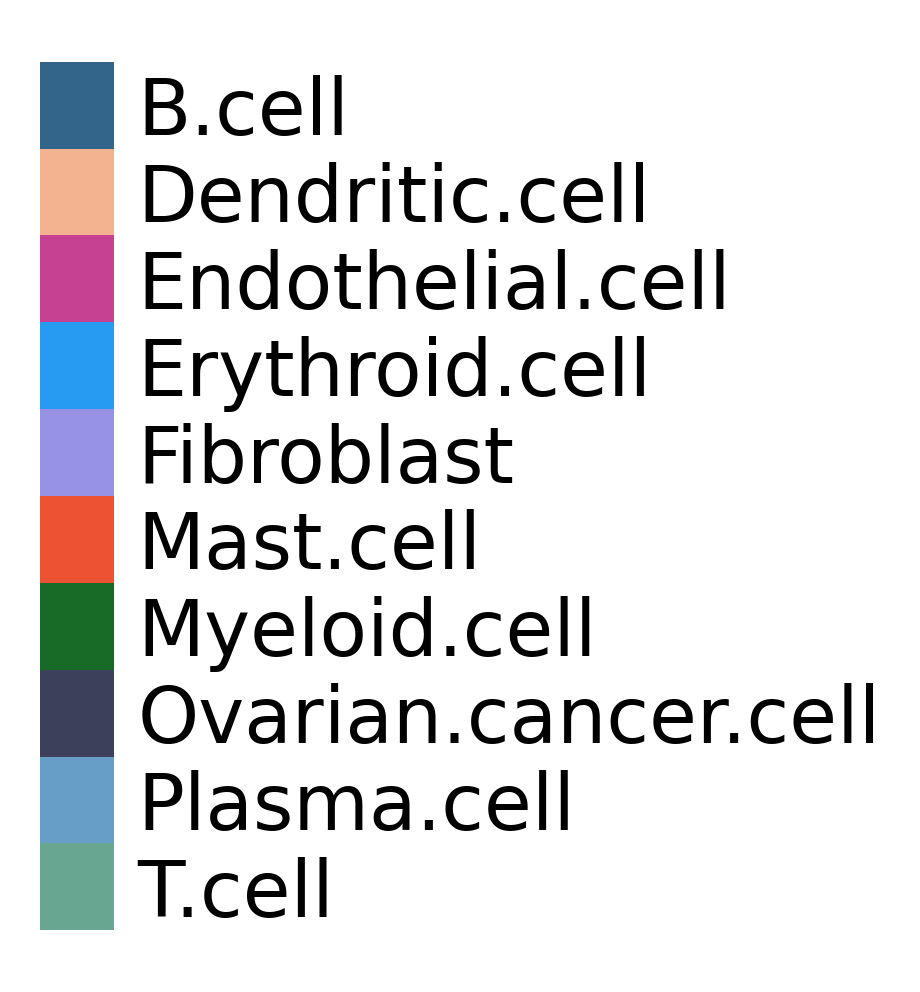

In [5]:
patch_plot(color_mapping_long)

In [10]:
patients_colors_EOC = {
    'EOC3': '#FFDF88',
    'EOC87': '#F1558E',
    'EOC204': '#EBA889',
    'EOC115': '#BC4B51',
    'EOC372': '#5B8E7D',
    'EOC136': '#8A89C0',
    'EOC153': '#0081AF',
    'EOC649': '#A6D49F',
    'EOC1127': '#90BEDE'
}

<Axes: >

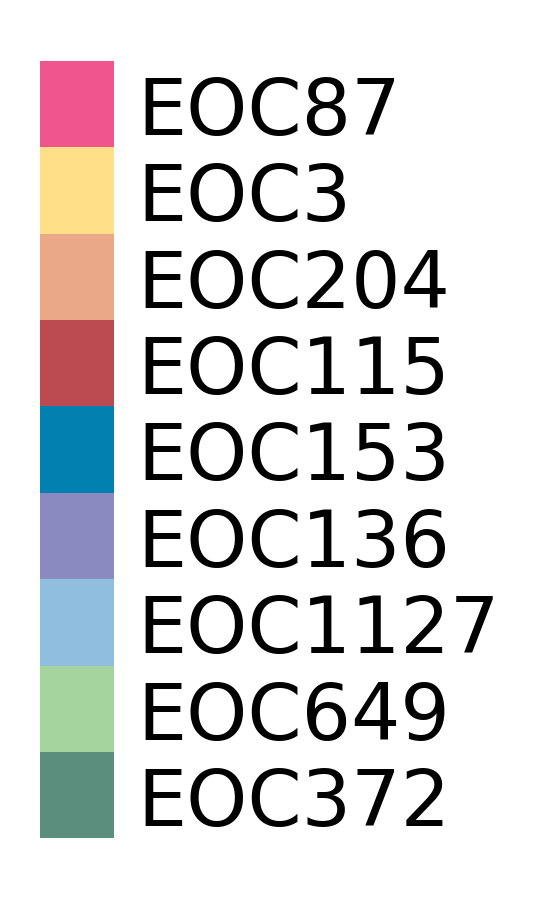

In [11]:
patch_plot(patients_colors_EOC, order=patients_ordered)

In [12]:
color_mapping_short = {
    'cancer': '#F78764',
    'immune': '#68A691',
    'stromal': '#742792'
}

<Axes: >

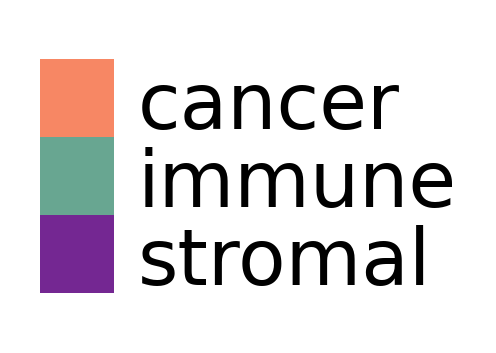

In [14]:
patch_plot(color_mapping_short)

In [15]:
HRD_palette = {
    'HRP': '#81A4CD',
    'HRD': '#FFA047'}

<Axes: >

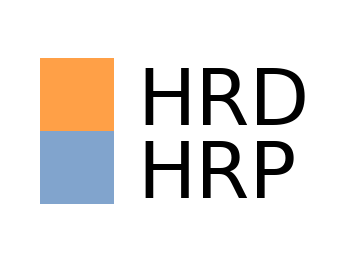

In [16]:
patch_plot(HRD_palette)

In [17]:
tissue_palette = {
    'Mesentary': '#6F9CEB',
    'Omentum': '#5B8C5A',
    'Peritoneum': '#7F2982'
}

<Axes: >

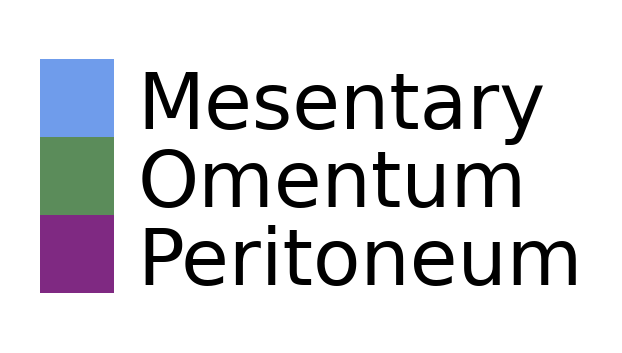

In [18]:
patch_plot(tissue_palette)

In [19]:
status_palette = {'Refractory': '#f28482',
                  'Sensitive': '#81b29a',
                  'Intermediate': '#4280A7'
                 }

In [20]:
status_palette_short = {'R': '#f28482',
                  'S': '#81b29a',
                  'Intermediate': '#4280A7'}

<Axes: >

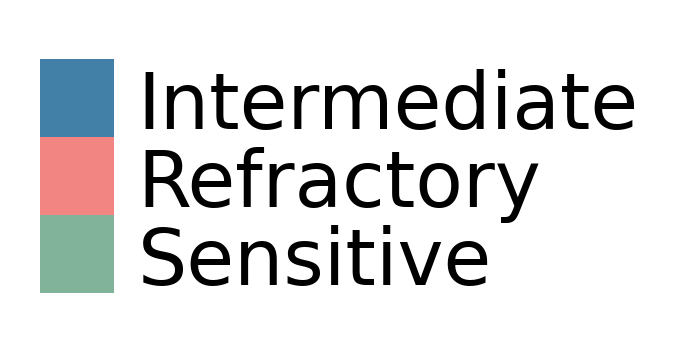

In [21]:
patch_plot(status_palette)

# Annotation

In [22]:
mymeta = pd.read_csv('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/Anna_SC_data/paper_data/meta_patients.tsv',
            sep='\t', index_col=0)
mymeta

,scRNA_sample,publication_code,Status,SBS3,tissue,Definition
EOC3,EOC3_pPer,EOC3,Refractory,HRP,Peritoneum,R
EOC87,EOC87_pPer,EOC87,Refractory,HRP,Peritoneum,R
EOC204,EOC204_pMes,EOC204,Refractory,HRD,Mesentary,R
EOC115,EOC115_pPer,EOC115,Refractory,HRP,Peritoneum,R
EOC372,EOC372_pPer,EOC372,Sensitive,HRD,Peritoneum,S
EOC136,EOC136_pMes,EOC136,Sensitive,HRD,Mesentary,S
EOC153,EOC153_pOme,EOC153,Sensitive,HRD,Omentum,S
EOC649,EOC649_pOme,EOC649,Sensitive,HRP,Omentum,S
EOC1127,EOC1127_pOme,EOC1127,Sensitive,HRP,Omentum,S


In [23]:
meta = pd.read_csv('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/Anna_SC_data/paper_data/meta_sample.tsv',
                   sep='\t', index_col=0)
meta.head(3)

,nCount_RNA,nFeature_RNA,log2nCount,log2nFeature,patient,percent.mt,nReads,log2nReads,nCount_SCT,cell_types_v2,NACT,celltype_updated,cell_name.1,scRNA_sample,publication_code,Status,SBS3,tissue,Definition
cell_name,,,,,,,,,,,,,,,,,,,
AAAGATGCAGACGTAG-8,3613,973,11.818982,9.926296,EOC649,2.158871,55379,15.757051,4395,immune,primary,T.cell,AAAGATGCAGACGTAG-8,EOC649_pOme,EOC649,Sensitive,HRP,Omentum,S
AAAGATGTCAGGATCT-8,4037,1621,11.979068,10.662668,EOC649,3.195442,53560,15.708868,4388,immune,primary,T.cell,AAAGATGTCAGGATCT-8,EOC649_pOme,EOC649,Sensitive,HRP,Omentum,S
AAAGCAACACGGTTTA-8,1714,515,10.743151,9.008429,EOC649,2.975496,23059,14.493042,3618,immune,primary,Plasma.cell,AAAGCAACACGGTTTA-8,EOC649_pOme,EOC649,Sensitive,HRP,Omentum,S


In [24]:
meta.shape

(19156, 19)

# Read counts

In [25]:
adata = sc.read_h5ad('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/Anna_SC_data/paper_data/adata_9patients_without_PCs.h5ad')

In [26]:
adata

AnnData object with n_obs × n_vars = 19156 × 58037
    obs: 'sample', 'patient_id', 'anatomical_location', 'cell_type', 'cell_type_updated', 'nCount_RNA', 'nFeature_RNA', 'nReads', 'log2nCount', 'log2nFeature', 'log2nReads', 'percent.mt', 'NACT', 'status', 'SBS3', 'cell_id'
    layers: 'counts'

## Normalizing the data

In [27]:
# Normalizing total counts per cell
print('normalize_total')
sc.pp.normalize_total(
    adata, 
    target_sum=1e4, 
    exclude_highly_expressed=True
)

# Logarithmic transformation
print('log1p')
sc.pp.log1p(adata)

# Identifying highly variable genes
print('highly_variable_genes')
sc.pp.highly_variable_genes(
    adata, 
    flavor='seurat_v3', 
    n_top_genes=2000, 
    subset=False 
)

# Save raw data
print('raw')
adata.raw = adata

# Regress out technical effects
print('regress_out')
sc.pp.regress_out(
    adata, 
    ['nCount_RNA', 'percent.mt'], 
    n_jobs=50
)

# Scaling the data
print('scale')
sc.pp.scale(adata, max_value=10)

# Storing normalized data in a layer
adata.layers['normalized'] = adata.X

normalize_total
log1p
highly_variable_genes


/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


raw
regress_out
scale


In [28]:
# Principal Component Analysis (PCA)
print('pca')
sc.tl.pca(
    adata, 
    svd_solver='arpack', 
    use_highly_variable=True, 
    random_state=41
)

# Constructing a neighborhood graph
print('neighbors')
sc.pp.neighbors(
    adata, 
    n_neighbors=15, 
    n_pcs=30, 
    random_state=41
)

# UMAP embedding
print('umap')
sc.tl.umap(
    adata, 
    random_state=41, 
    spread=1., 
    min_dist=0.5
)

pca
neighbors


/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/l

umap


In [106]:
adata.obs['cell_type_updated'].value_counts()

T.cell                 5576
Ovarian.cancer.cell    5567
Myeloid.cell           4104
Fibroblast             3187
Plasma.cell             336
B.cell                  209
Dendritic.cell           75
Mast.cell                55
Endothelial.cell         47
Name: cell_type_updated, dtype: int64

# Markers expression check

In [35]:
# Epithelial cancer cells: WFDC2, PAX8, MUC16
# Stromal cells: COL12A, FGFR1, DCN
# Immune cells: CD14, CD3D, CD79B, CD8A, FCER1G, HLA-DRA, NKG7, PTPRC

In [36]:
mrks = {
    'EOC': ['WFDC2', 'PAX8', 'MUC16'],
    'Stromal': ['COL1A2', 'FGFR1', 'DCN'],
    'Immune': ['CD14', 'CD3D','CD79B', 'CD8A', 'FCER1G', 'HLA-DRA', 'NKG7', 'PTPRC']
}

In [37]:
adata.obs['cell_type_updated'].value_counts()

T.cell                 5576
Ovarian.cancer.cell    5567
Myeloid.cell           4104
Fibroblast             3187
Plasma.cell             336
B.cell                  209
Dendritic.cell           75
Mast.cell                55
Endothelial.cell         47
Name: cell_type_updated, dtype: int64

/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


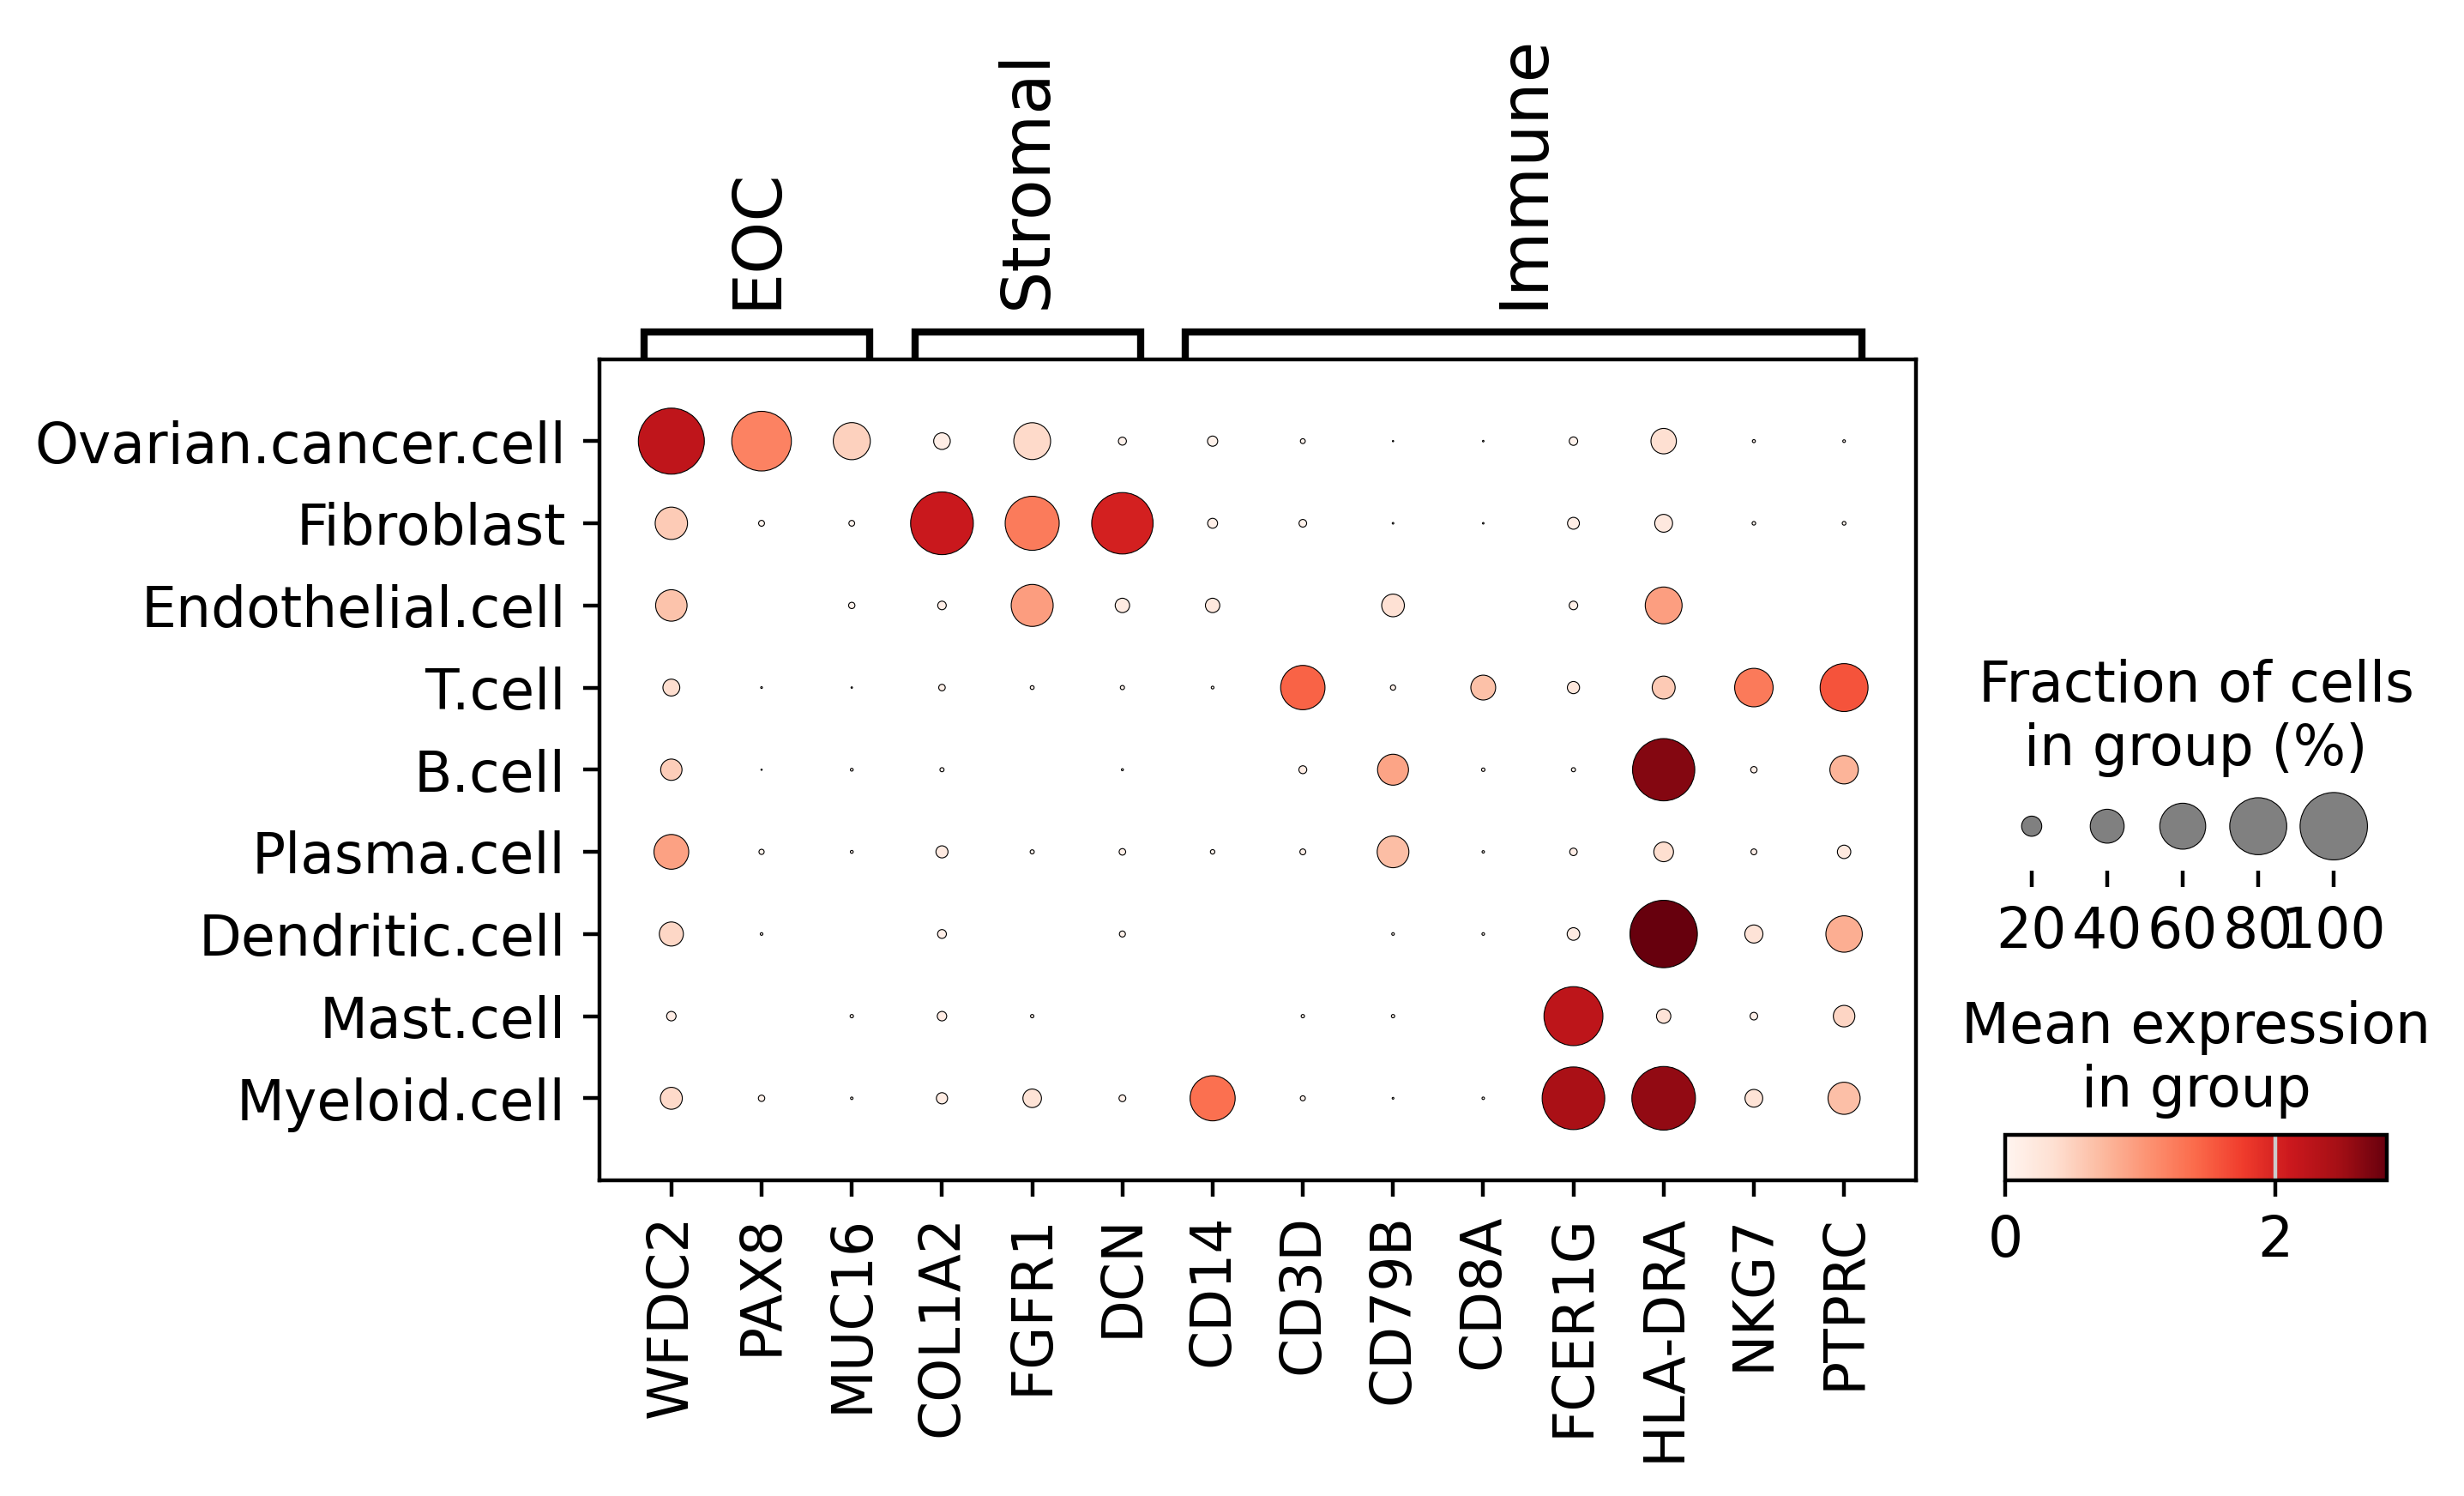

In [38]:
dp = sc.pl.dotplot(adata,
                   mrks,
                   'cell_type_updated',
                   show=False,
                   categories_order=['Ovarian.cancer.cell', 'Fibroblast', 'Endothelial.cell',
                                     'T.cell', 'B.cell', 'Plasma.cell', 'Dendritic.cell',
                                     'Mast.cell', 'Myeloid.cell'], 
                   smallest_dot=0
                  )

# dp['mainplot_ax'].figure.savefig(\
#             "/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/sc_dotplot_9patients_annmarkers.pdf",
#                                  dpi=600, bbox_inches='tight')

# QC check

In [39]:
meta.columns

Index(['nCount_RNA', 'nFeature_RNA', 'log2nCount', 'log2nFeature', 'patient',
       'percent.mt', 'nReads', 'log2nReads', 'nCount_SCT', 'cell_types_v2',
       'NACT', 'celltype_updated', 'cell_name.1', 'scRNA_sample',
       'publication_code', 'Status', 'SBS3', 'tissue', 'Definition'],
      dtype='object')

In [40]:
# The percentage of UMI counts originating from mitochondrial gene
#
# < 20 for all cell types -- NEW

meta.groupby('cell_types_v2')['percent.mt'].max() 

cell_types_v2
cancer     19.993894
immune     19.971333
stromal    19.956803
Name: percent.mt, dtype: float64

# UMAP full data

In [41]:
adata.obs.columns

Index(['sample', 'patient_id', 'anatomical_location', 'cell_type',
       'cell_type_updated', 'nCount_RNA', 'nFeature_RNA', 'nReads',
       'log2nCount', 'log2nFeature', 'log2nReads', 'percent.mt', 'NACT',
       'status', 'SBS3', 'cell_id'],
      dtype='object')

In [42]:
sc.set_figure_params(figsize=(10, 8), frameon=False,
                     dpi_save=600, vector_friendly=True)
sc.settings.n_jobs=2

/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


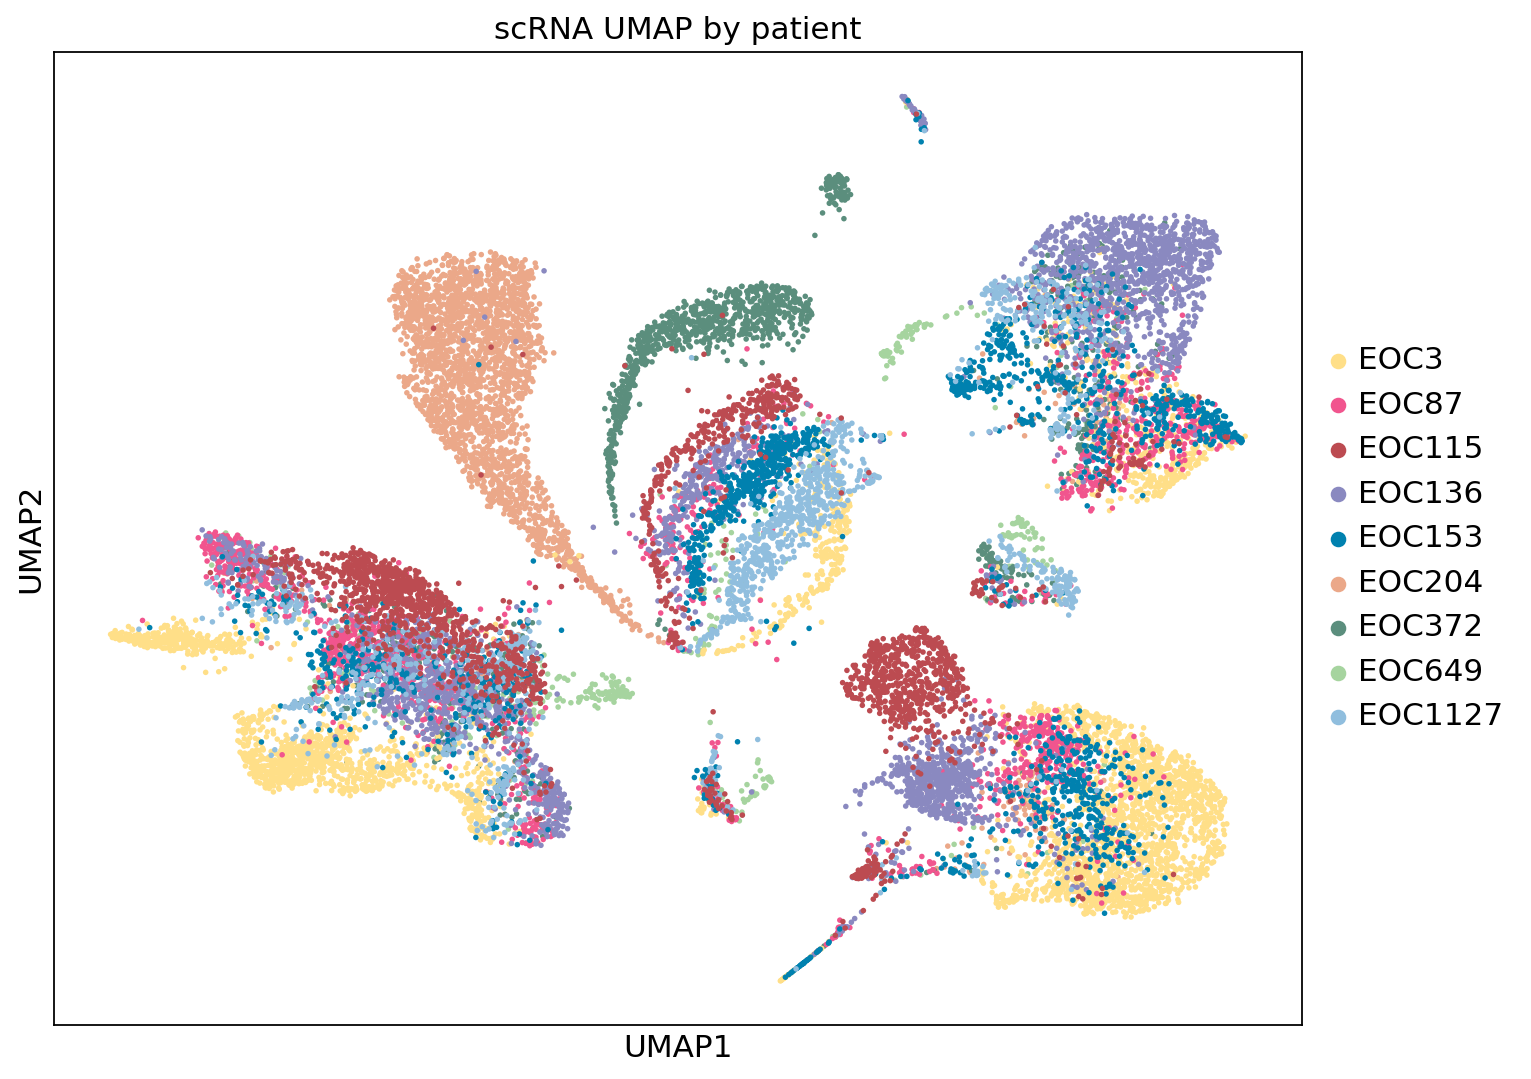

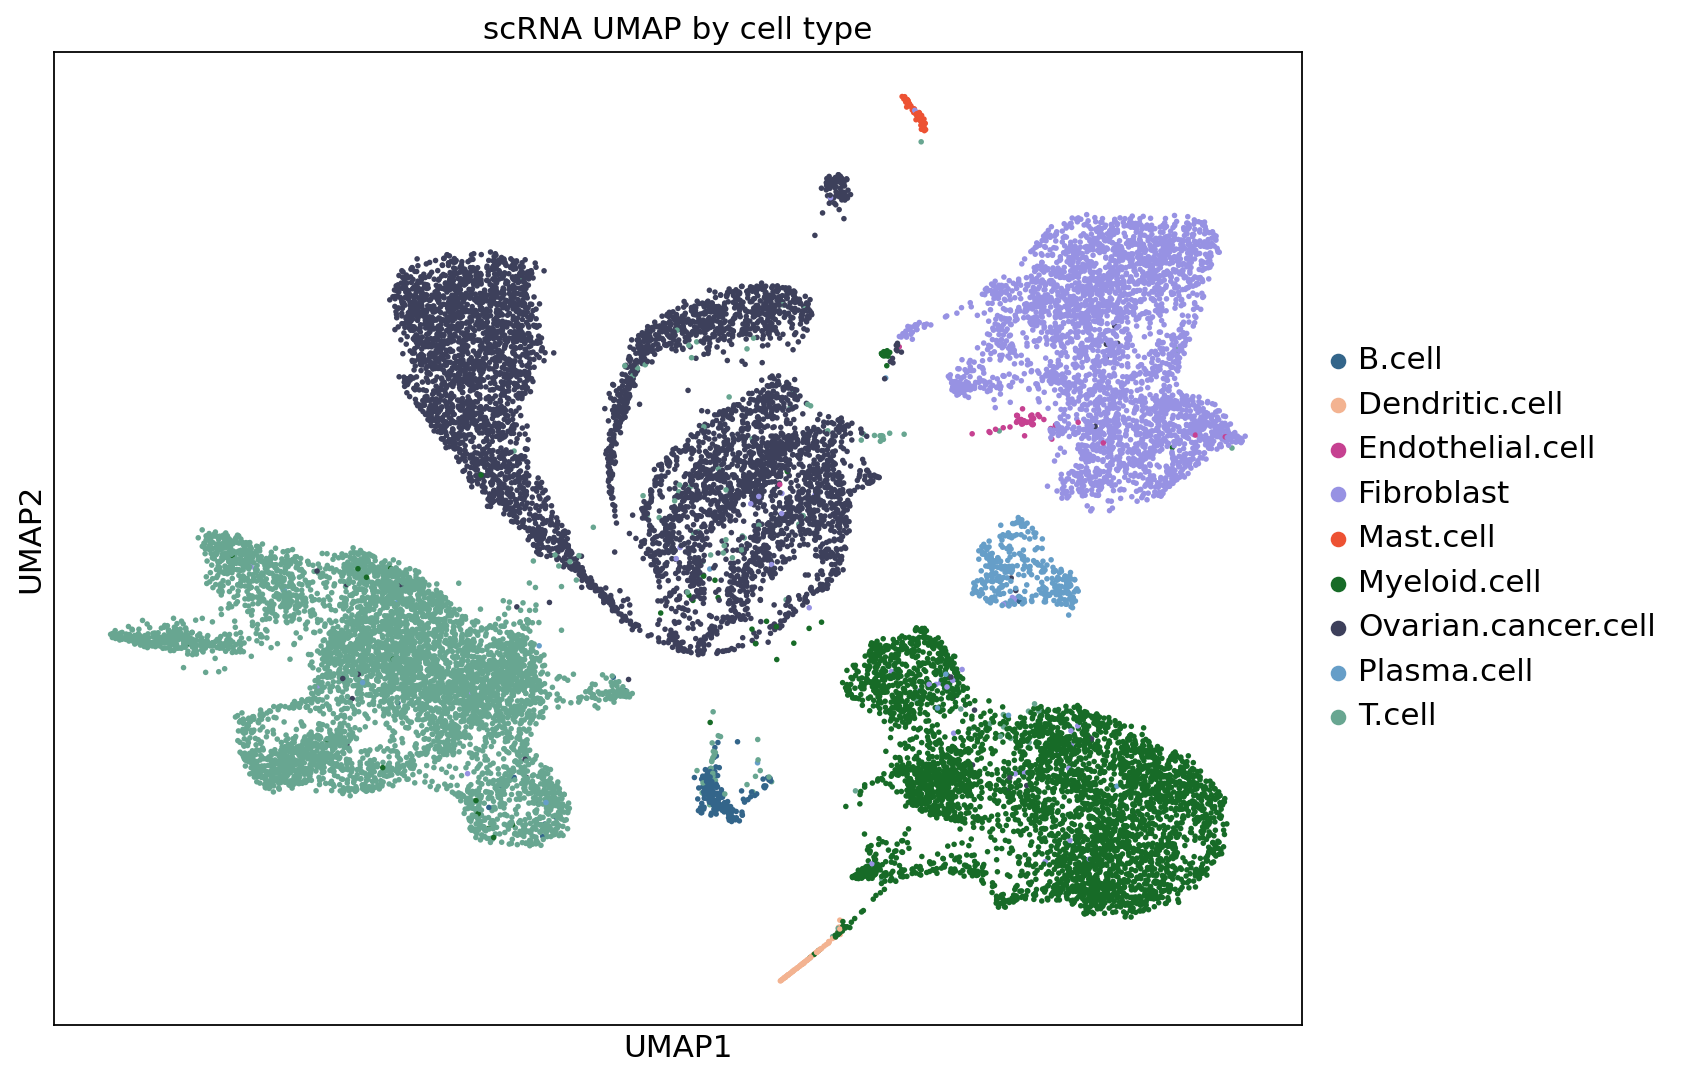

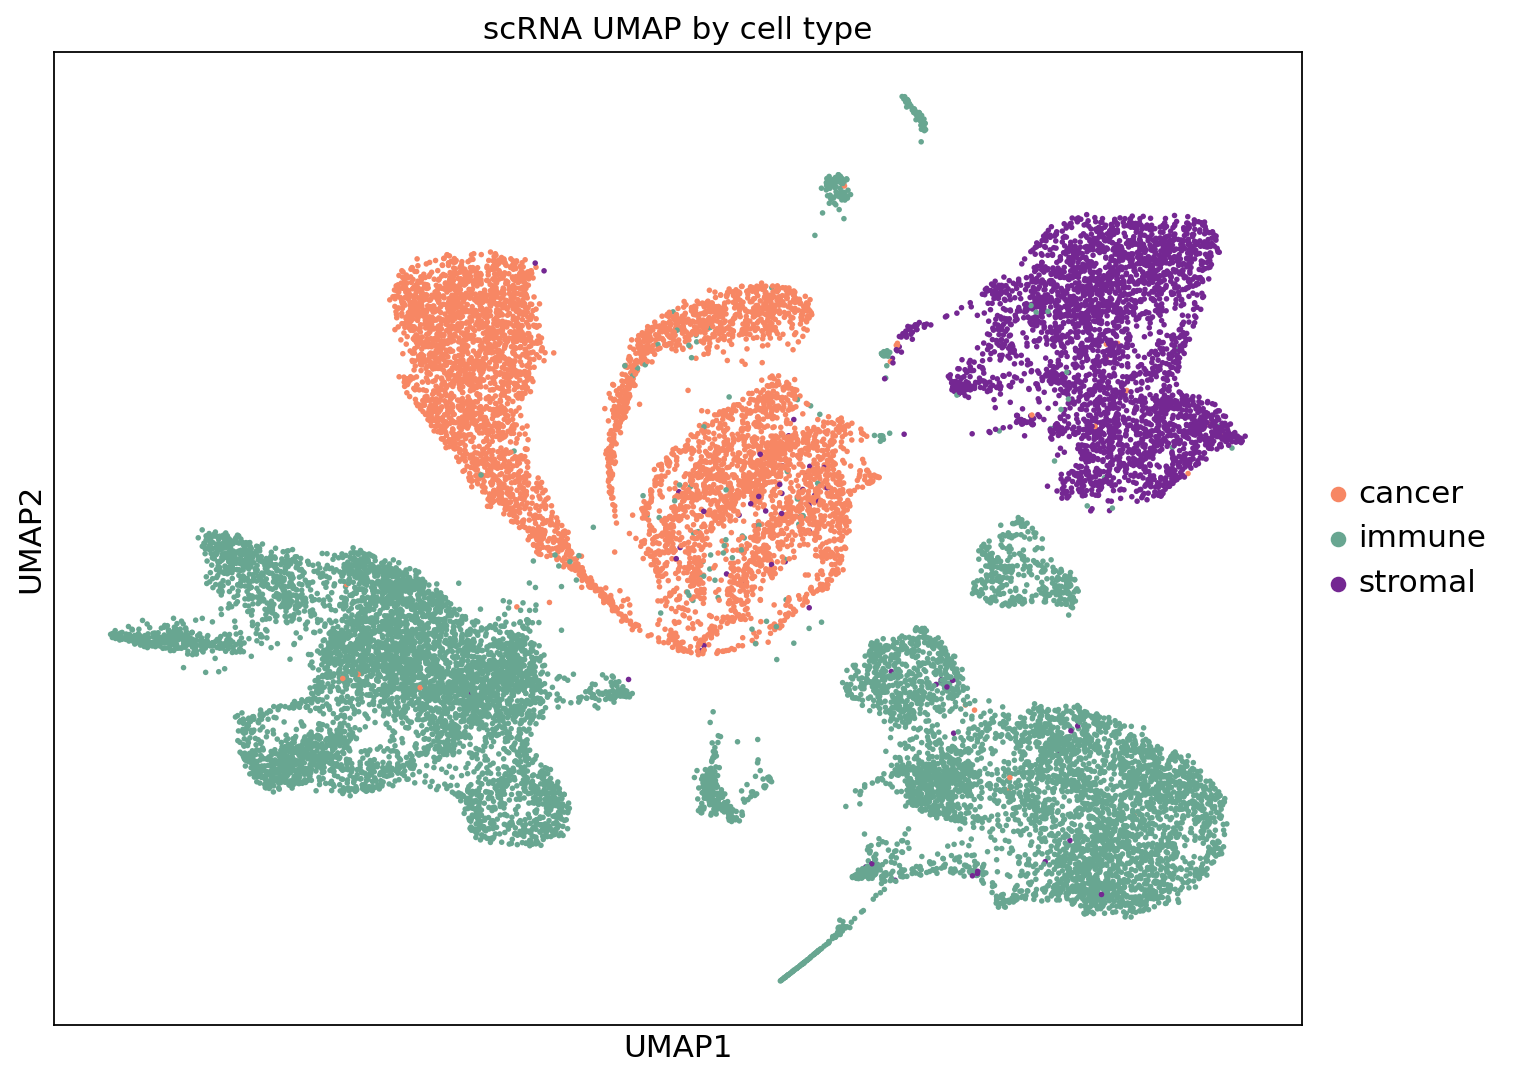

In [43]:
f1 = sc.pl.umap(adata,
                color='patient_id',
                title='scRNA UMAP by patient',
                frameon=True,
                legend_fontweight='normal',
                legend_fontsize=14,
                s=25,
                palette=patients_colors_EOC,
                return_fig=True)

# plt.savefig(\
#             "/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/UMAP_by_patient_allcells.pdf",
#                                  dpi=600, bbox_inches='tight')

f2 = sc.pl.umap(adata,
                color='cell_type_updated',
                title='scRNA UMAP by cell type',
                frameon=True,
                legend_fontweight='normal',
                legend_fontsize=14,
                s=25,
                palette=color_mapping_long,
                return_fig=True)

# plt.savefig(\
#             "/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/UMAP_by_celltype_allcells.pdf",
#                                  dpi=600, bbox_inches='tight')

f3 = sc.pl.umap(adata,
                color='cell_type',
                title='scRNA UMAP by cell type',
                frameon=True,
                legend_fontweight='normal',
                legend_fontsize=14,
                s=25,
                palette=color_mapping_short,
                return_fig=True)

# plt.savefig(\
#             "/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/UMAP_by_3celltype_allcells.pdf",
#                                  dpi=600, bbox_inches='tight')

# Boxplot with TME

In [44]:
meta = adata.obs.copy()

In [45]:
meta.columns

Index(['sample', 'patient_id', 'anatomical_location', 'cell_type',
       'cell_type_updated', 'nCount_RNA', 'nFeature_RNA', 'nReads',
       'log2nCount', 'log2nFeature', 'log2nReads', 'percent.mt', 'NACT',
       'status', 'SBS3', 'cell_id'],
      dtype='object')

In [46]:
meta.cell_type.value_counts()

immune     10475
cancer      5449
stromal     3232
Name: cell_type, dtype: int64

In [47]:
meta_copy = meta.copy()
cell_counts = meta.groupby(['patient_id', 'cell_type']).size().reset_index(name='count')

total_counts = meta_copy.groupby(['patient_id']).size().reset_index(name='total_count')
proportions = pd.merge(cell_counts, total_counts, on=['patient_id'])
proportions['proportion'] = proportions['count'] / proportions['total_count']

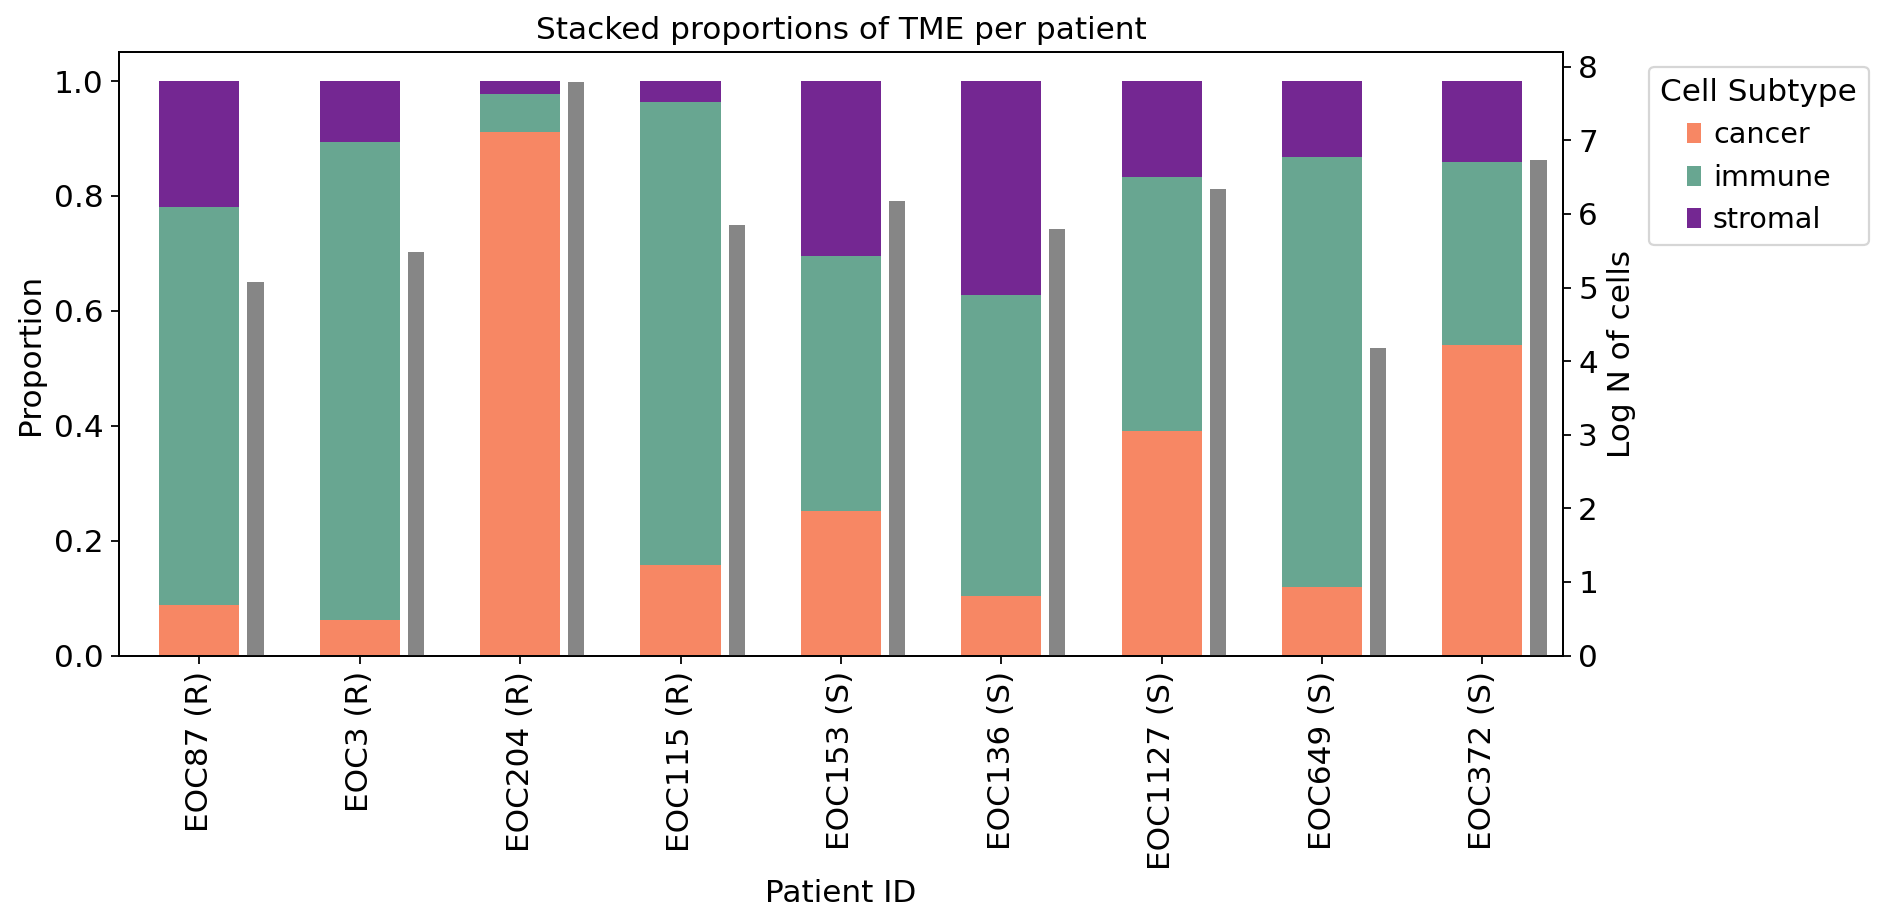

In [48]:
pivot_df = proportions.pivot(index='patient_id',
                             columns='cell_type',
                             values='proportion').fillna(0)

pat_order = patients_ordered
pivot_df = pivot_df.loc[pat_order]

fig, ax = plt.subplots(figsize=(12, 6))
pivot_df.plot(kind='bar',
              stacked=True,
              color=[color_mapping_short[sub] for sub in pivot_df.columns],
              ax=ax)

ax.set_title(f'Stacked proportions of TME per patient')
ax.set_ylabel('Proportion')
ax.set_xlabel('Patient ID')
ax.legend(title='Cell Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(
    [x + f" ({mymeta.loc[x, 'Definition']})" for x in patients_ordered],
    rotation=90, fontsize=14
)
plt.tight_layout()
plt.grid(False)

ax2 = ax.twinx()
counts = [
    np.log1p(x) for x in list(meta_copy[meta_copy.cell_type == 'cancer']
    .groupby('patient_id')['cell_type']
    .count().loc[patients_ordered].values)
]
ax2.bar(
    [x + 0.35 for x in range(len(patients_ordered))],
    counts, width=0.1, color='grey', alpha=0.95
)
ax2.set_ylabel('Log N of cells')
ax2.set_ylim(0, max(counts) + 0.4)

plt.tight_layout()
plt.grid(False)

# plt.savefig(\
#             "/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/Barplot_composition_3celltypes.pdf",
#                                  dpi=600, bbox_inches='tight')

In [49]:
meta_copy = meta.copy()
cell_counts = meta.groupby(['patient_id', 'cell_type_updated']).size().reset_index(name='count')

total_counts = meta_copy.groupby(['patient_id']).size().reset_index(name='total_count')
proportions = pd.merge(cell_counts, total_counts, on=['patient_id'])
proportions['proportion'] = proportions['count'] / proportions['total_count']

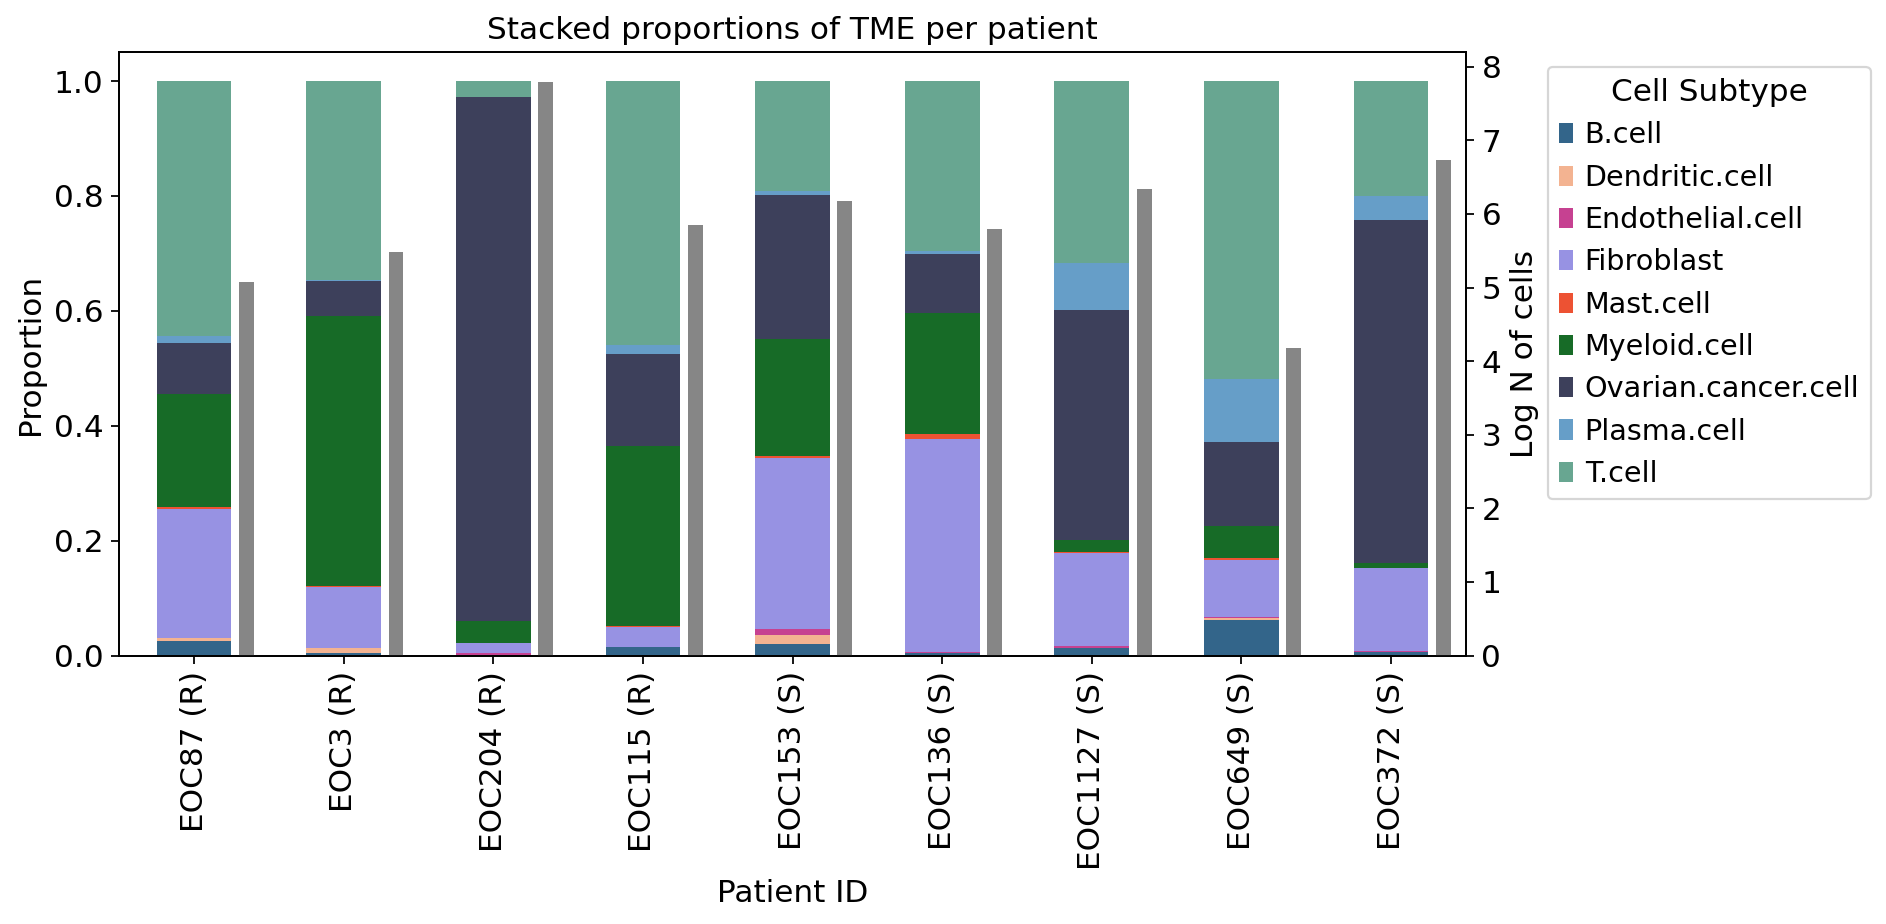

In [50]:
pivot_df = proportions.pivot(index='patient_id',
                             columns='cell_type_updated',
                             values='proportion').fillna(0)

pat_order = patients_ordered
pivot_df = pivot_df.loc[pat_order]

fig, ax = plt.subplots(figsize=(12, 6))
pivot_df.plot(kind='bar',
              stacked=True,
              color=[color_mapping_long[sub] for sub in pivot_df.columns],
              ax=ax)

ax.set_title(f'Stacked proportions of TME per patient')
ax.set_ylabel('Proportion')
ax.set_xlabel('Patient ID')
ax.legend(title='Cell Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(
    [x + f" ({mymeta.loc[x, 'Definition']})" for x in patients_ordered],
    rotation=90, fontsize=14
)
plt.tight_layout()
plt.grid(False)

ax2 = ax.twinx()
counts = [
    np.log1p(x) for x in list(meta_copy[meta_copy.cell_type == 'cancer']
    .groupby('patient_id')['cell_type']
    .count().loc[patients_ordered].values)
]
ax2.bar(
    [x + 0.35 for x in range(len(patients_ordered))],
    counts, width=0.1, color='grey', alpha=0.95
)
ax2.set_ylabel('Log N of cells')
ax2.set_ylim(0, max(counts) + 0.4)

plt.tight_layout()
plt.grid(False)

# plt.savefig(\
#             "/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/Barplot_composition_allcelltypes.pdf",
#                                  dpi=600, bbox_inches='tight')

In [52]:
adata.obs.columns

Index(['sample', 'patient_id', 'anatomical_location', 'cell_type',
       'cell_type_updated', 'nCount_RNA', 'nFeature_RNA', 'nReads',
       'log2nCount', 'log2nFeature', 'log2nReads', 'percent.mt', 'NACT',
       'status', 'SBS3', 'cell_id'],
      dtype='object')

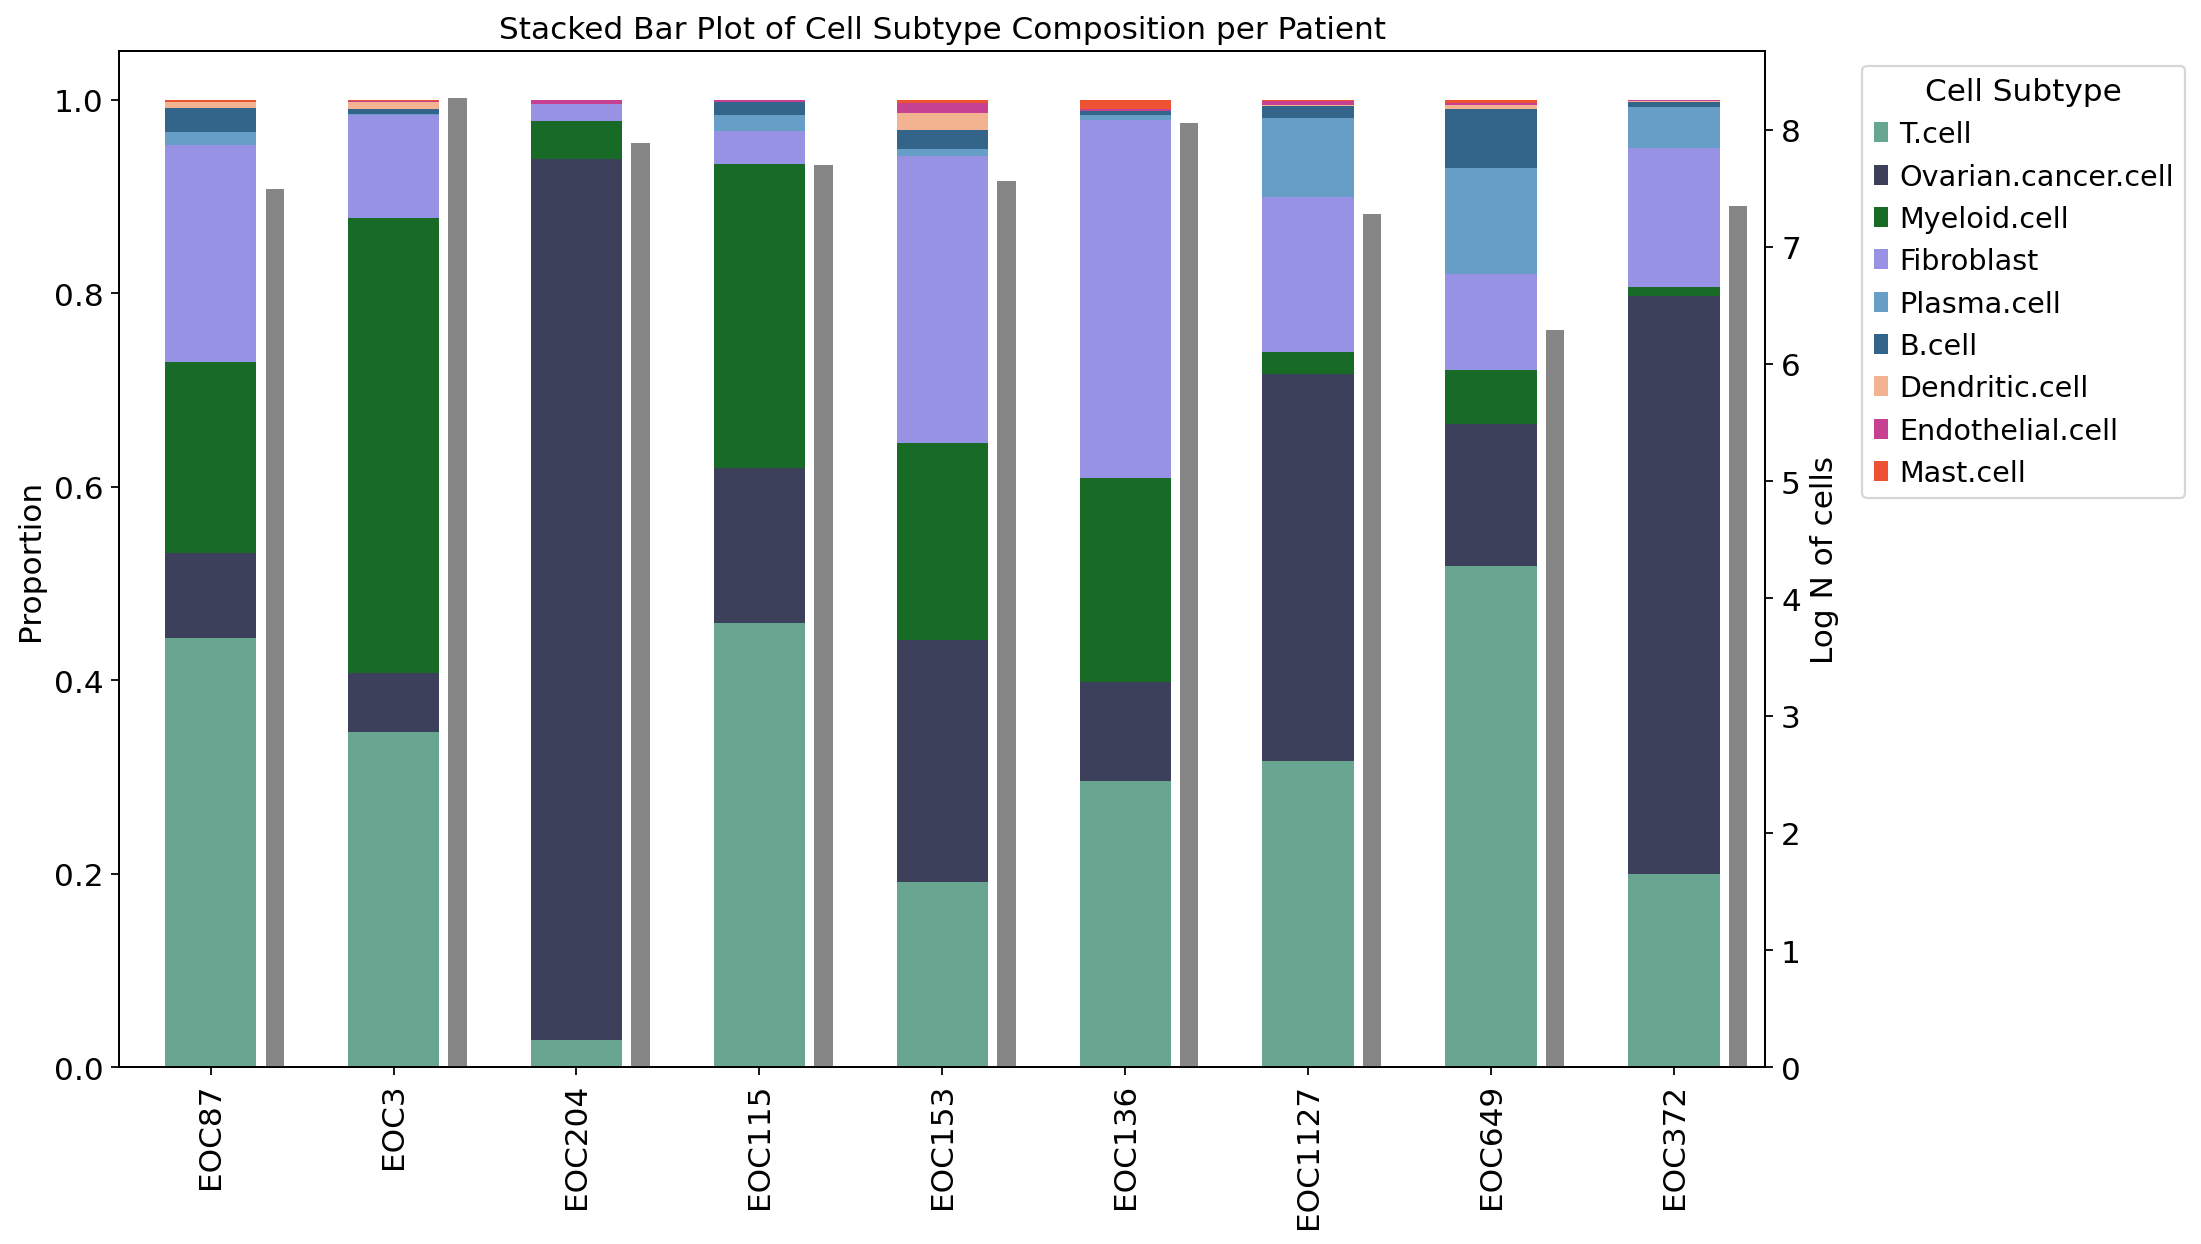

In [57]:
cell_subtype_counts = adata.obs.groupby(['patient_id', 'cell_type_updated']).size().unstack(fill_value=0)
cell_subtype_counts = cell_subtype_counts.reindex(patients_ordered)
cell_subtype_proportions = cell_subtype_counts.div(cell_subtype_counts.sum(axis=1), axis=0)
sorted_df = cell_subtype_proportions[cell_subtype_proportions.mean().sort_values(ascending=False).index]


fig, ax = plt.subplots()

sorted_df.plot(kind='bar', stacked=True,
                              figsize=(14, 8),
                              color=[color_mapping_long[x] for x in sorted_df.columns],
                             ax=ax)

plt.title('Stacked Bar Plot of Cell Subtype Composition per Patient')
plt.ylabel('Proportion')
plt.xlabel('')
plt.legend(title='Cell Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)
plt.grid(False)
ax2 = ax.twinx()
counts=[np.log1p(x) for x in list(adata.obs.groupby(['patient_id']).size()\
    .loc[patients_ordered].values)]
ax2.bar([x + 0.35 for x in range(9)],
        counts, width=0.1, color='grey', alpha=0.95 )
ax2.set_ylabel('Log N of cells')
ax2.set_ylim(0, max(counts) + 0.4) 
plt.tight_layout()
plt.grid(False)

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/Barplot_composition_allcelltypes.pdf',
#             format='pdf', dpi=600, bbox_inches='tight')

plt.show()

In [58]:
cell_subtype_proportions.mean(axis=0).sort_values()[::-1]

cell_type_updated
T.cell                 0.311066
Ovarian.cancer.cell    0.302010
Myeloid.cell           0.168864
Fibroblast             0.161744
Plasma.cell            0.030633
B.cell                 0.016473
Dendritic.cell         0.003865
Endothelial.cell       0.002708
Mast.cell              0.002637
dtype: float64

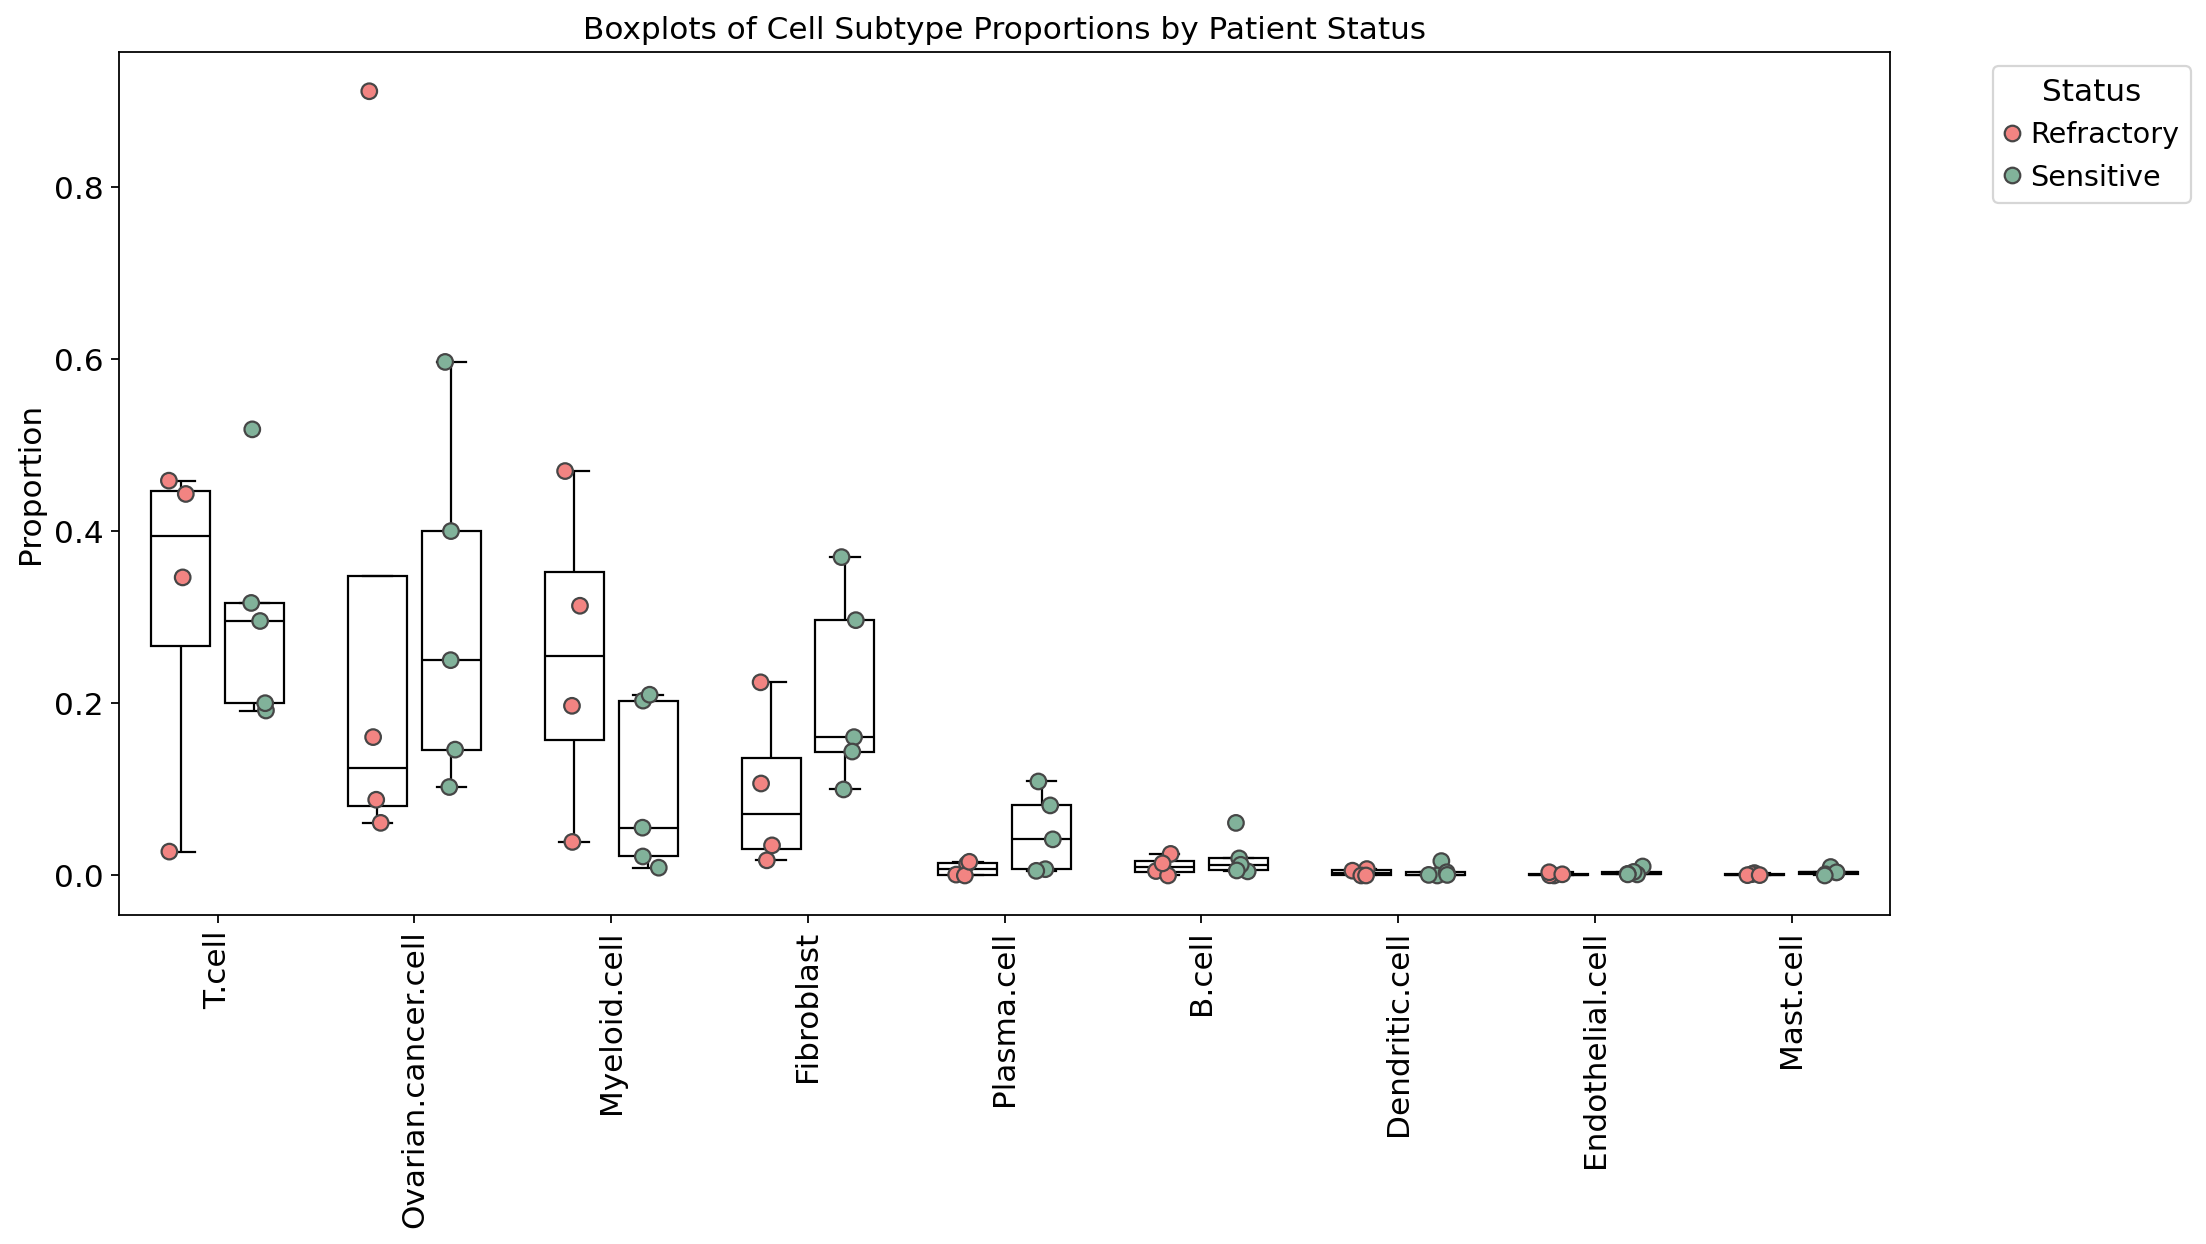

In [62]:
mean_proportions = cell_subtype_proportions.mean().sort_values(ascending=False)
cell_subtype_proportions = cell_subtype_proportions[mean_proportions.index]

melted_df = cell_subtype_proportions.reset_index().melt(id_vars=['patient_id'],
                                                        var_name='cell_type_updated',
                                                        value_name='proportion')

merged_df = pd.merge(melted_df,
                     adata.obs[['patient_id', 'status']].drop_duplicates(),
                     on='patient_id')

p_values = {}

for subtype in merged_df['cell_type_updated'].unique():

    responsive = merged_df[(merged_df['cell_type_updated'] == subtype) &\
                           (merged_df['status'] == 'Responsive')]['proportion'].fillna(0)
    refractory = merged_df[(merged_df['cell_type_updated'] == subtype) &\
                           (merged_df['status'] == 'Refractory')]['proportion'].fillna(0)
    
    t_stat, p_val = ttest_ind(responsive, refractory, equal_var=False)  # Use Welch's t-test
    p_values[subtype] = p_val

plt.figure(figsize=(14, 8))

sns.boxplot(x='cell_type_updated',
            y='proportion',
            hue='status',
            data=merged_df,
            palette={'Refractory': 'white', 'Sensitive': 'white'},
            showfliers=False, width=0.75, gap=0.2,
            linecolor='black', linewidth=1, legend=False)

sns.stripplot(x='cell_type_updated',
              y='proportion',
              hue='status',
              data=merged_df, 
              dodge=True,
              jitter=True,
              marker='o',
              alpha=1.,
              palette=status_palette,
              size=7, linewidth=1)

handles, labels = plt.gca().get_legend_handles_labels()
l = plt.legend(handles[0:2], labels[0:2], title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Boxplots of Cell Subtype Proportions by Patient Status')
plt.ylabel('Proportion')
plt.xlabel('')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)

for subtype, p_val in p_values.items():
    if p_val < 0.05: 
        plt.text(
            x=merged_df['cell_type_updated'].unique().tolist().index(subtype), 
            y=0.8, 
            s=f'p = {p_val:.3f}', 
            ha='center', 
            va='bottom', 
            color='red'
        )

plt.grid(False)
plt.tight_layout()

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/Boxplot_TME_sc.pdf',
#             format='pdf', dpi=600, bbox_inches='tight')

plt.show()

# IFN across compartments

In [64]:
# Filter by hallmark
msigdb = dc.get_resource('MSigDB')
msigdb = msigdb[msigdb['collection']=='hallmark']

# Remove duplicated entries
msigdb = msigdb[~msigdb.duplicated(['geneset', 'genesymbol'])]
msigdb.head(3)

,genesymbol,collection,geneset
11,MSC,hallmark,HALLMARK_TNFA_SIGNALING_VIA_NFKB
149,ICOSLG,hallmark,HALLMARK_TNFA_SIGNALING_VIA_NFKB
223,ICOSLG,hallmark,HALLMARK_INFLAMMATORY_RESPONSE


In [65]:
msigdb.head(3)

,genesymbol,collection,geneset
11,MSC,hallmark,HALLMARK_TNFA_SIGNALING_VIA_NFKB
149,ICOSLG,hallmark,HALLMARK_TNFA_SIGNALING_VIA_NFKB
223,ICOSLG,hallmark,HALLMARK_INFLAMMATORY_RESPONSE


In [66]:
dc.run_ora(
    mat=adata,
    net=msigdb,
    source='geneset',
    target='genesymbol',
    verbose=True
)

16693 features of mat are empty, they will be removed.
Running ora on mat with 19156 samples and 41344 targets for 50 sources.


100%|██████████████████████████████████████████████████████████████| 19156/19156 [00:37<00:00, 513.60it/s]


In [67]:
acts_msigdb = dc.get_acts(adata, obsm_key='ora_estimate')

# We need to remove inf and set them to the maximum value observed
acts_msigdb_v = acts_msigdb.X.ravel()
max_e = np.nanmax(acts_msigdb_v[np.isfinite(acts_msigdb_v)])
acts_msigdb.X[~np.isfinite(acts_msigdb.X)] = max_e

acts_msigdb

/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 19156 × 50
    obs: 'sample', 'patient_id', 'anatomical_location', 'cell_type', 'cell_type_updated', 'nCount_RNA', 'nFeature_RNA', 'nReads', 'log2nCount', 'log2nFeature', 'log2nReads', 'percent.mt', 'NACT', 'status', 'SBS3', 'cell_id'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'patient_id_colors', 'cell_type_updated_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'ora_estimate', 'ora_pvals'

In [68]:
acts_msigdb.obs['HALLMARK_INTERFERON_ALPHA_RESPONSE'] =\
acts_msigdb.obsm['ora_estimate']['HALLMARK_INTERFERON_ALPHA_RESPONSE']

In [69]:
acts_msigdb.obs = acts_msigdb.obs.rename(columns={'HALLMARK_INTERFERON_ALPHA_RESPONSE':
                                    'HALLMARK_IFN_ALPHA_RESPONSE'})

In [70]:
sc.set_figure_params(figsize=(10, 8), frameon=False,
                     dpi_save=600, vector_friendly=True)
sc.settings.n_jobs=2

/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


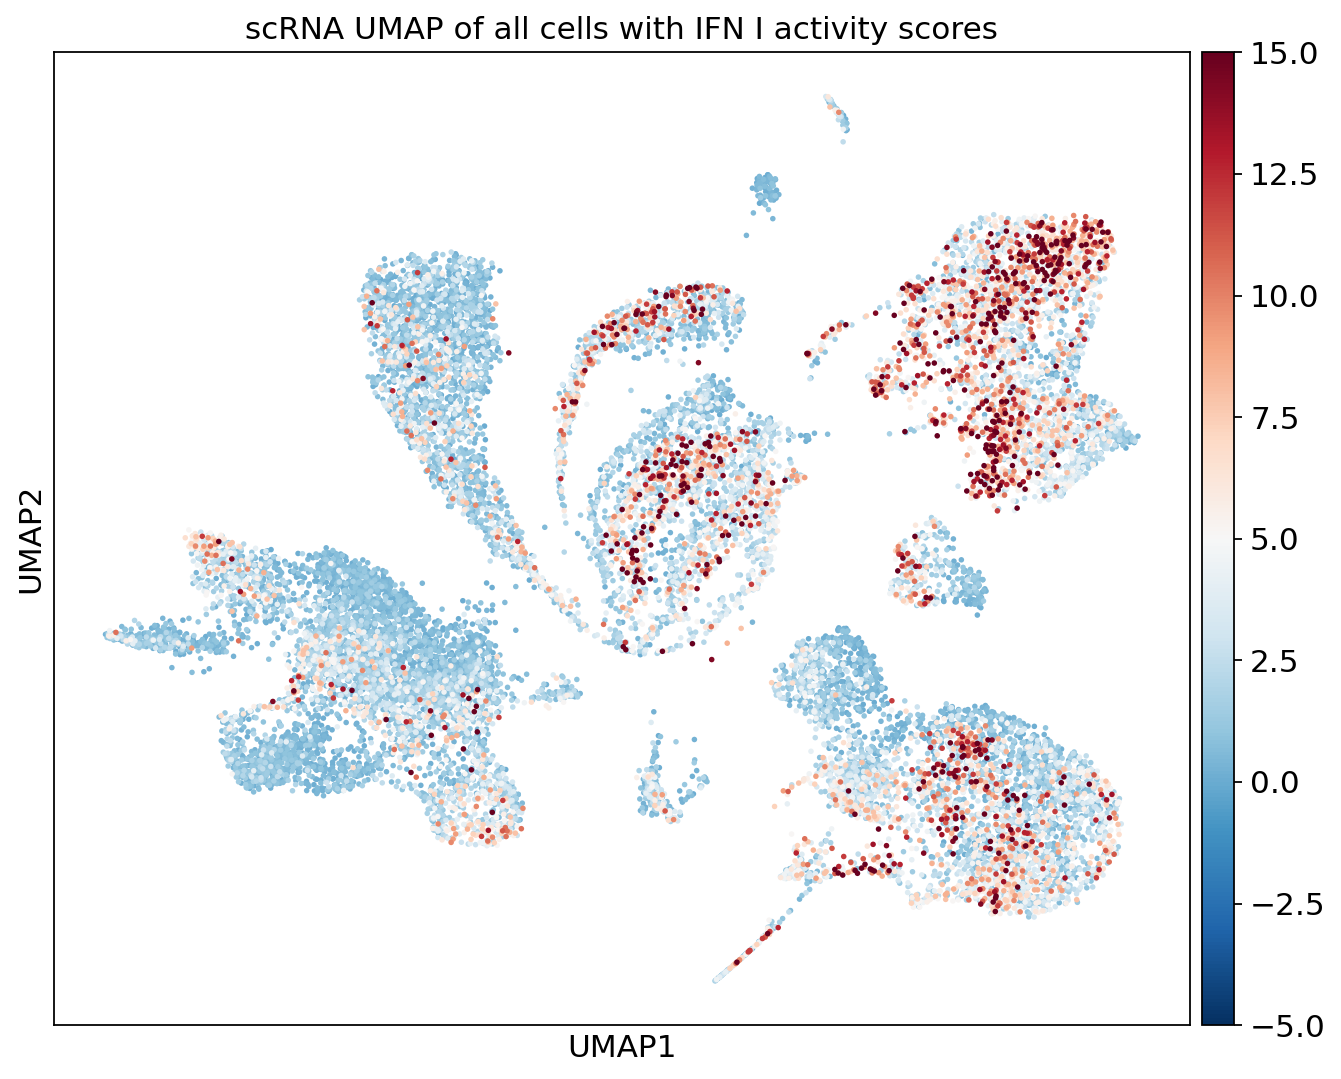

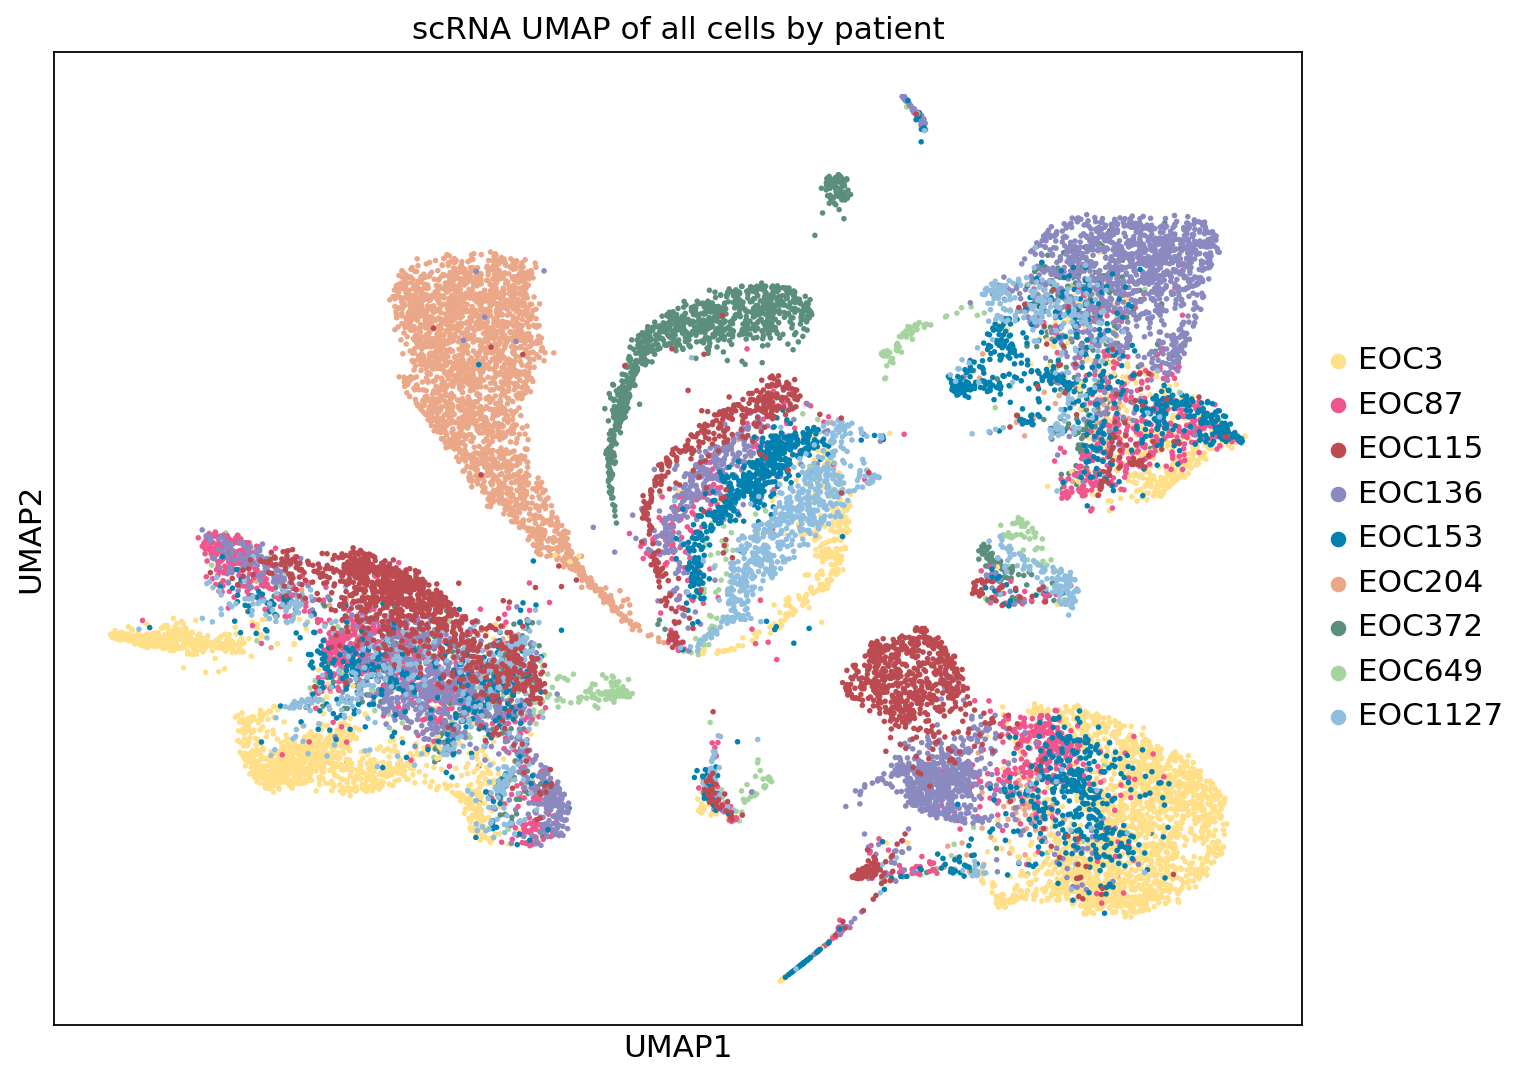

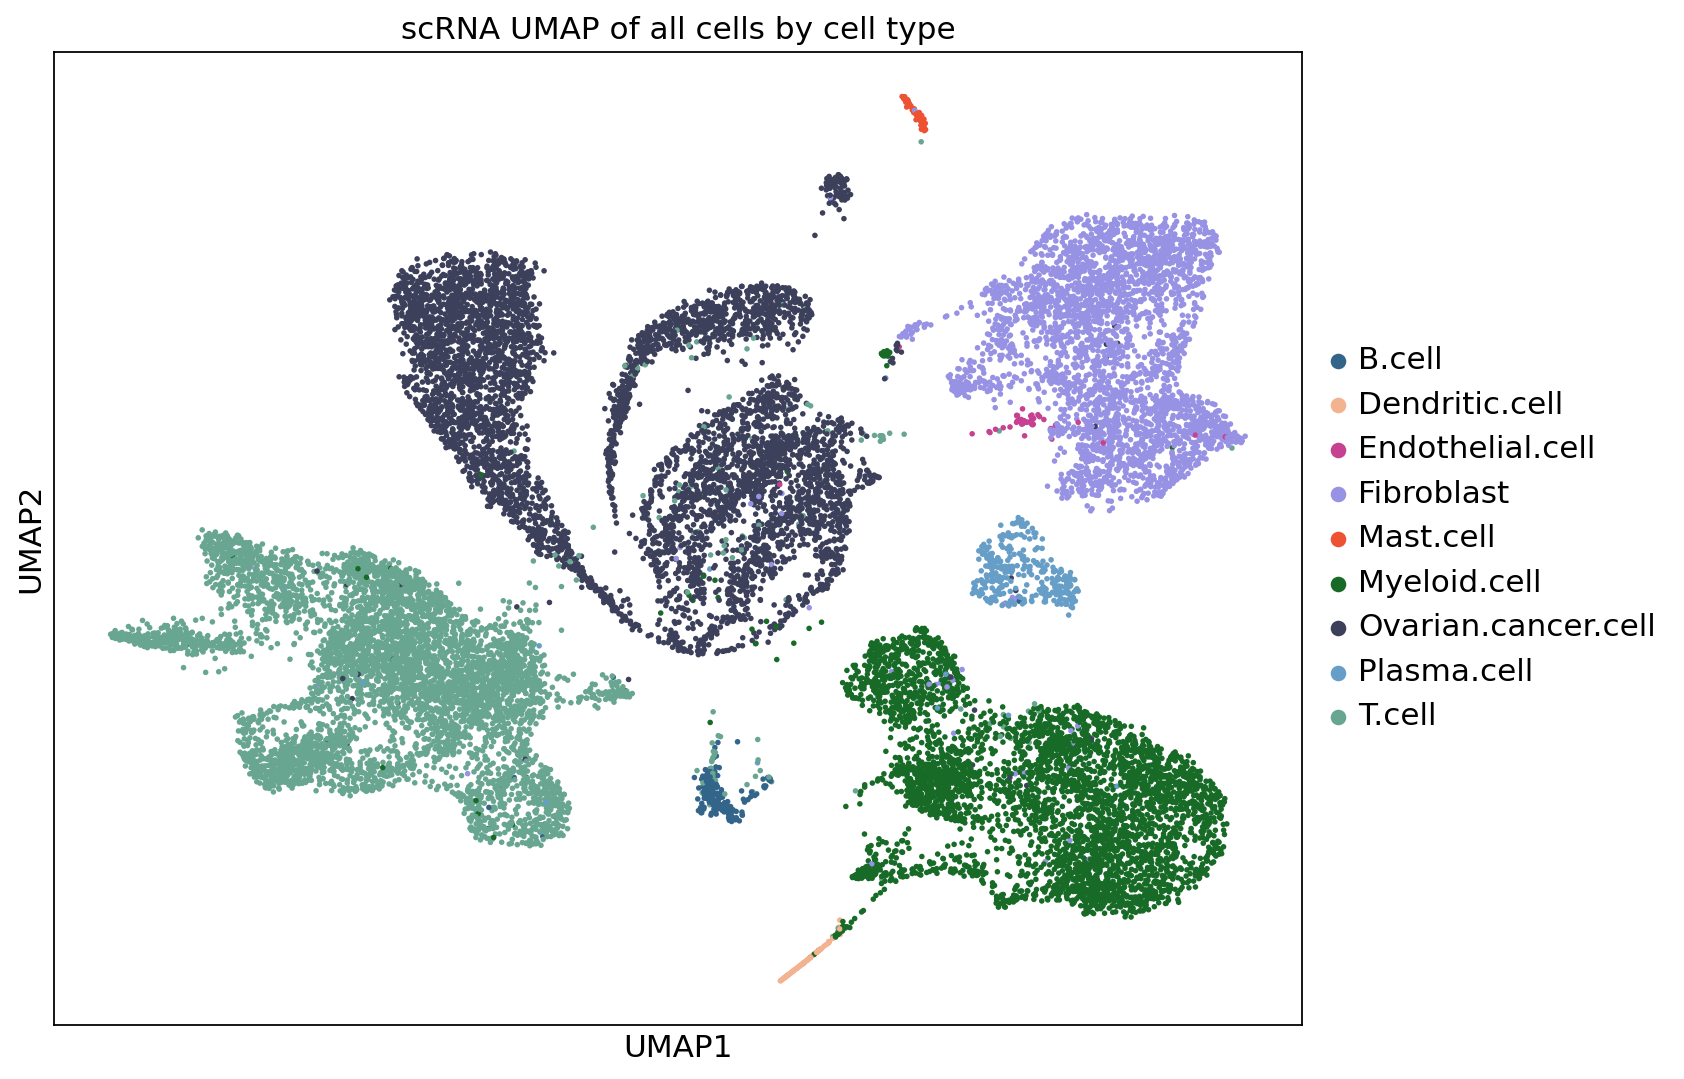

In [102]:
f1 = sc.pl.umap(acts_msigdb,
                color='HALLMARK_INTERFERON_ALPHA_RESPONSE',
                title='scRNA UMAP of all cells with IFN I activity scores',
                frameon=True,
                legend_fontweight='normal',
                cmap='RdBu_r',
                vmax=15, vmin=-5,
                legend_fontsize=14,
                s=25,
                return_fig=True)
# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/scRNA_UMAP_IFNa.pdf',
#             format='pdf', dpi=600, bbox_inches='tight')

f2 = sc.pl.umap(acts_msigdb,
                color='patient_id',
                title='scRNA UMAP of all cells by patient',
                frameon=True,
                legend_fontweight='normal',
                palette=patients_colors_EOC,
                legend_fontsize=14,
                s=25,
                return_fig=True)
# plt.savefig('/mnt/storageBig8/work/afenteva/ChemoRef/REVIEW1/scRNA/figures/scRNA_UMAP_patient.pdf',
#             format='pdf', dpi=600, bbox_inches='tight')

f3 = sc.pl.umap(acts_msigdb,
                color='cell_type_updated',
                title='scRNA UMAP of all cells by cell type',
                frameon=True,
                legend_fontweight='normal',
                palette=color_mapping_long,
                legend_fontsize=14,
                s=25,
                return_fig=True)
# plt.savefig('/mnt/storageBig8/work/afenteva/ChemoRef/REVIEW1/scRNA/figures/scRNA_UMAP_celltype.pdf',
#             format='pdf', dpi=600, bbox_inches='tight')

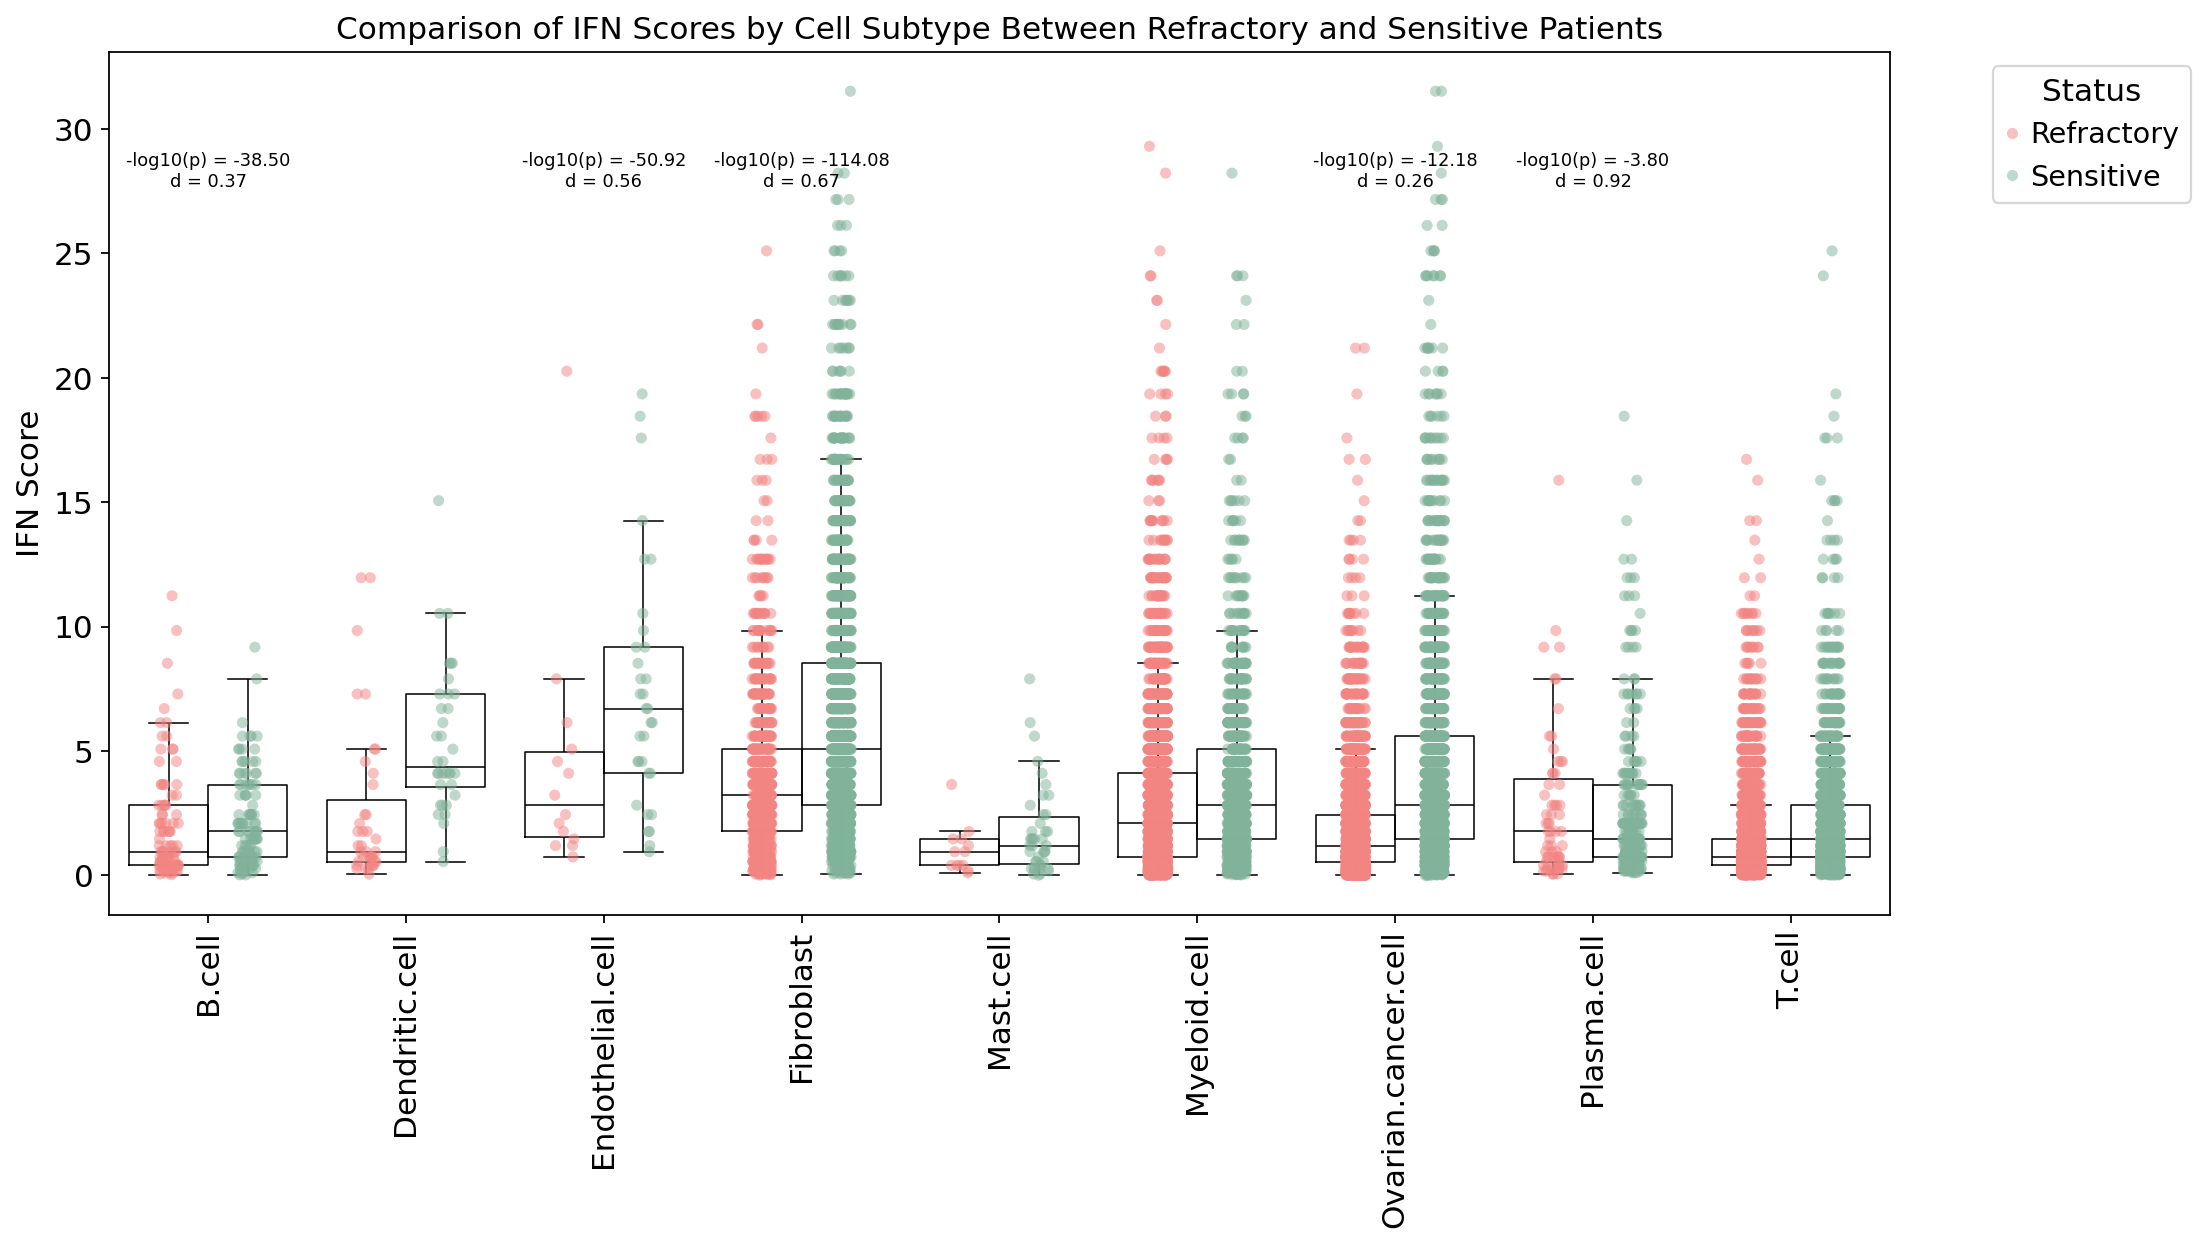

In [80]:
from numpy import log10

def cohen_d(x, y):
    if len(x) == 0 or len(y) == 0:
        return float('nan') 
    if x.std() == 0 or y.std() == 0:
        return float('nan') 
    return (x.mean() - y.mean()) / ((x.std() ** 2 + y.std() ** 2) / 2) ** 0.5

df = acts_msigdb.obs
p_values = {}
effect_sizes = {}

for subtype in df['cell_type_updated'].unique():
    
    responsive = df[(df['cell_type_updated'] == subtype) & (df['status'] == 'Sensitive')]['HALLMARK_IFN_ALPHA_RESPONSE'].dropna()
    refractory = df[(df['cell_type_updated'] == subtype) & (df['status'] == 'Refractory')]['HALLMARK_IFN_ALPHA_RESPONSE'].dropna()
    
    t_stat, p_val = ttest_ind(responsive, refractory, equal_var=False) 
    effect_size = cohen_d(responsive, refractory)
    
    p_values[subtype] = p_val
    effect_sizes[subtype] = effect_size

plt.figure(figsize=(14, 8))

sns.boxplot(x='cell_type_updated', y='HALLMARK_IFN_ALPHA_RESPONSE',
            hue='status', data=df, showfliers=False, fill=False,
            palette={'Refractory': 'black', 'Sensitive': 'black'},
            linewidth=0.7, legend=False)

sns.stripplot(x='cell_type_updated', y='HALLMARK_IFN_ALPHA_RESPONSE', hue='status', data=df, 
              dodge=True, jitter=True, marker='o', alpha=0.5, palette=status_palette, legend=True)

handles, labels = plt.gca().get_legend_handles_labels()
l = plt.legend(handles[0:2], labels[0:2], title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Comparison of IFN Scores by Cell Subtype Between Refractory and Sensitive Patients')
plt.ylabel('IFN Score')
plt.xlabel('')
plt.xticks(rotation=90)

for subtype, p_val in p_values.items():
    if p_val < 0.05: 
        effect_size = effect_sizes[subtype]
        plt.text(
            x=df['cell_type_updated'].unique().tolist().index(subtype), 
            y=max(df['HALLMARK_IFN_ALPHA_RESPONSE']) - 4, 
            s=f'-log10(p) = {log10(p_val):.2f}\nd = {effect_size:.2f}', 
            ha='center', 
            va='bottom', 
            color='black', 
            size=8
        )
        
plt.grid(False)
plt.tight_layout()

# Show the plot
plt.show()

In [84]:
adata.obs['cell_type_updated'].unique()

['T.cell', 'Plasma.cell', 'Fibroblast', 'Ovarian.cancer.cell', 'B.cell', 'Endothelial.cell', 'Myeloid.cell', 'Dendritic.cell', 'Mast.cell']
Categories (9, object): ['B.cell', 'Dendritic.cell', 'Endothelial.cell', 'Fibroblast', ..., 'Myeloid.cell', 'Ovarian.cancer.cell', 'Plasma.cell', 'T.cell']

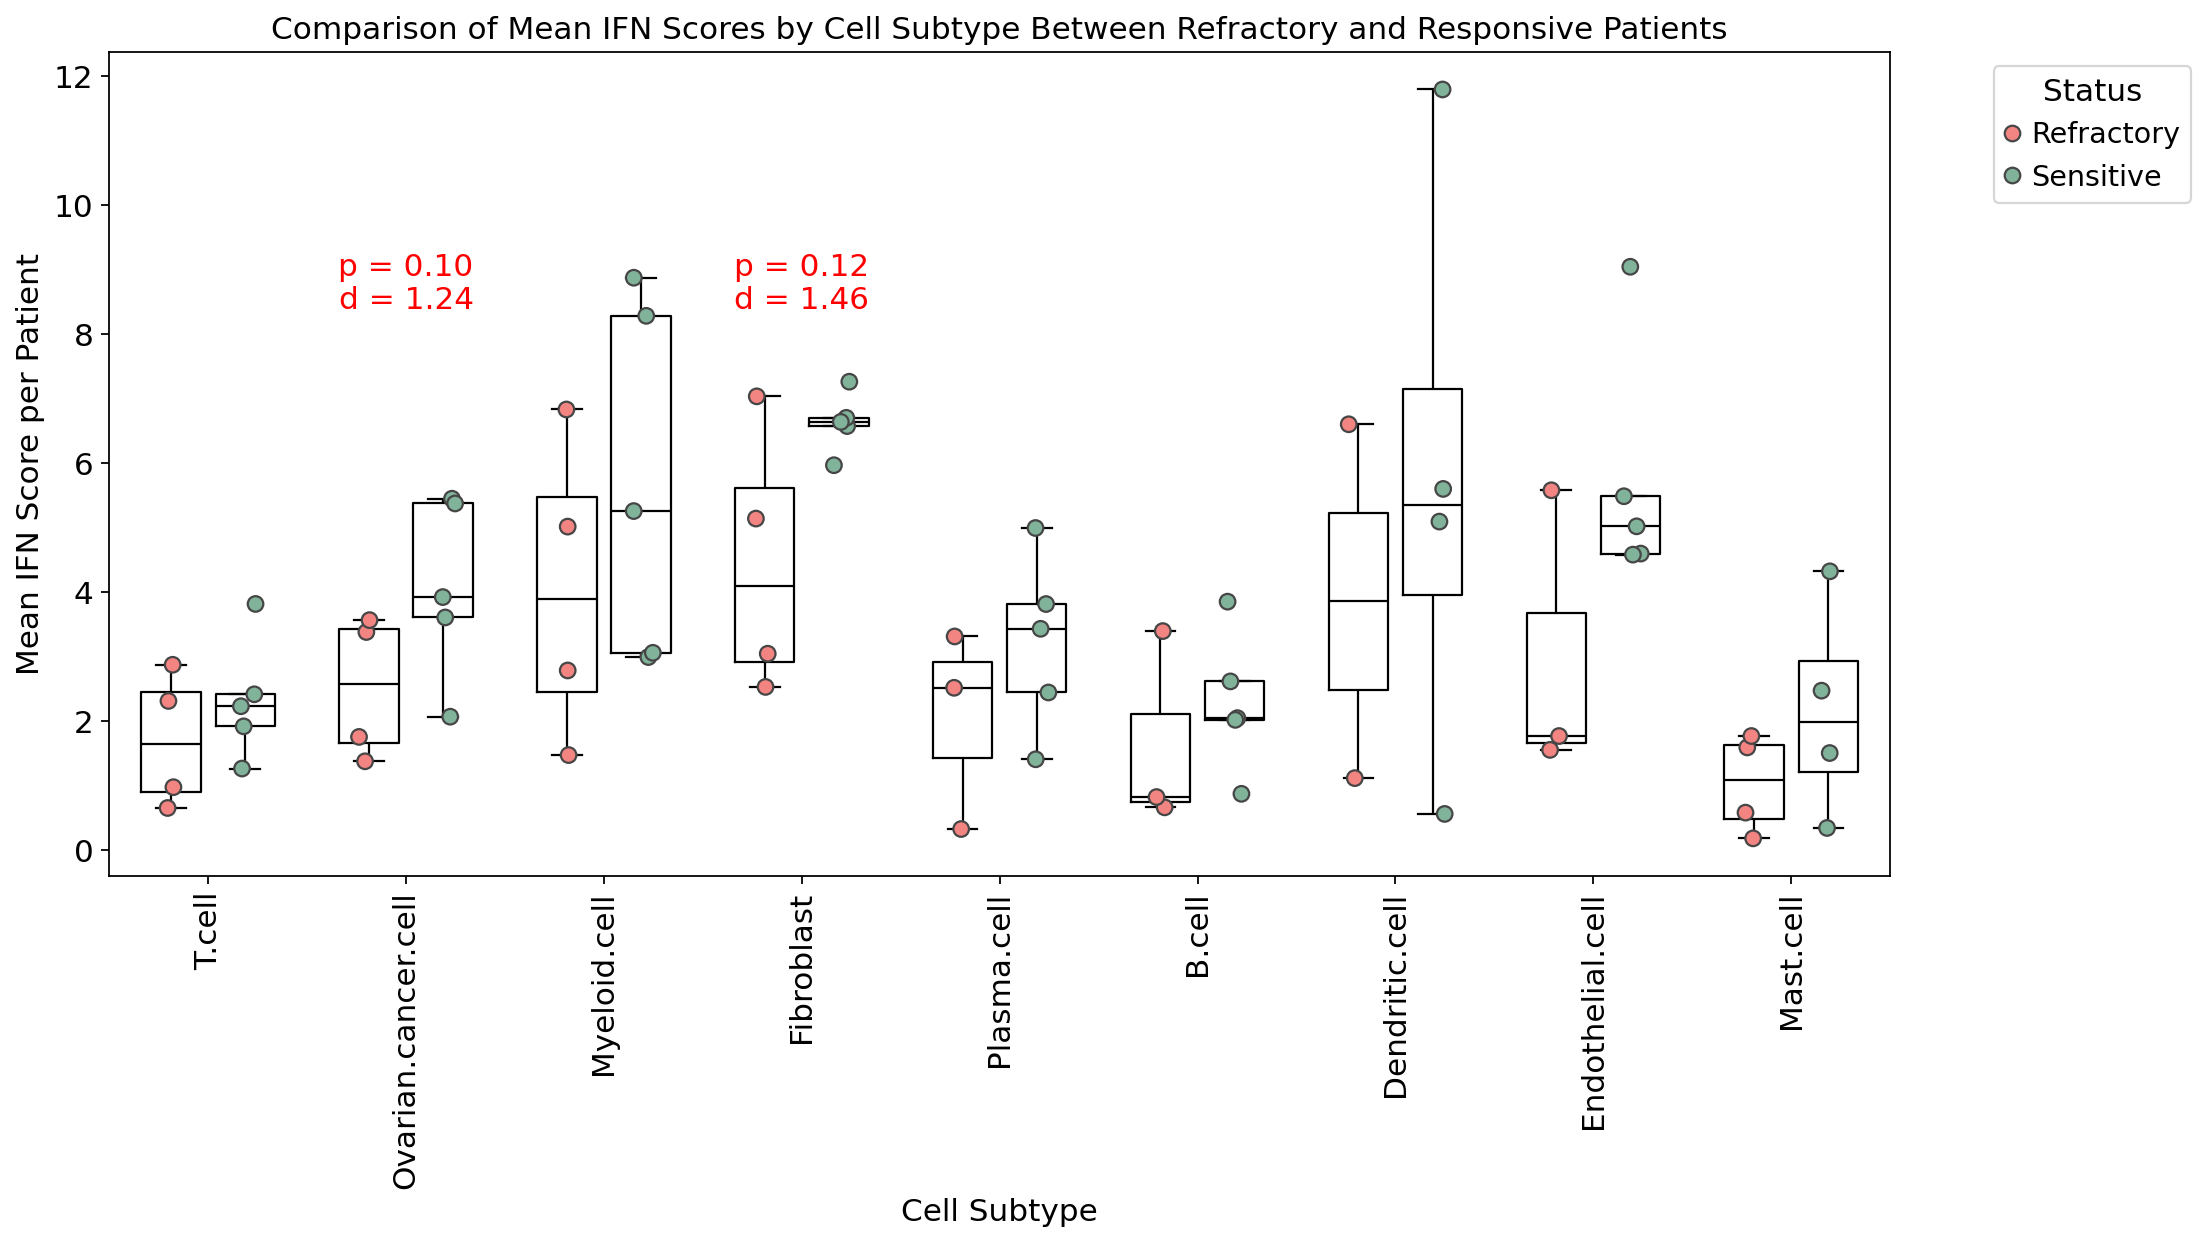

In [100]:
cell_type_order = [
    'T.cell', 'Ovarian.cancer.cell', 'Myeloid.cell', 'Fibroblast', 
    'Plasma.cell', 'B.cell', 'Dendritic.cell',
    'Endothelial.cell', 'Mast.cell'
]

median_ifn_scores = df.groupby(['patient_id', 'cell_type_updated', 'status'])['HALLMARK_IFN_ALPHA_RESPONSE'].mean().reset_index()

p_values = {}
effect_sizes = {}

for subtype in median_ifn_scores['cell_type_updated'].unique():
    responsive = median_ifn_scores[
        (median_ifn_scores['cell_type_updated'] == subtype) & 
        (median_ifn_scores['status'] == 'Sensitive')
    ]['HALLMARK_IFN_ALPHA_RESPONSE'].dropna()

    refractory = median_ifn_scores[
        (median_ifn_scores['cell_type_updated'] == subtype) & 
        (median_ifn_scores['status'] == 'Refractory')
    ]['HALLMARK_IFN_ALPHA_RESPONSE'].dropna()

    t_stat, p_val = ttest_ind(responsive, refractory, equal_var=False)  # Welch's t-test
    effect_size = cohen_d(responsive, refractory)
    
    p_values[subtype] = p_val
    effect_sizes[subtype] = effect_size

plt.figure(figsize=(14, 8))

sns.boxplot(x='cell_type_updated', y='HALLMARK_IFN_ALPHA_RESPONSE',
            hue='status', data=median_ifn_scores,
            legend=False,
            showfliers=False, fill=False, order=cell_type_order,
            palette={'Refractory': 'black', 'Sensitive': 'black'},
            width=0.75, linewidth=1, gap=0.2,)

sns.stripplot(x='cell_type_updated', y='HALLMARK_IFN_ALPHA_RESPONSE', 
              hue='status', data=median_ifn_scores, 
              dodge=True, jitter=True, marker='o',
              alpha=1.0, palette=status_palette, size=7, linewidth=1, 
              order=cell_type_order)

handles, labels = plt.gca().get_legend_handles_labels()
l = plt.legend(handles[0:2], labels[0:2], title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Comparison of Mean IFN Scores by Cell Subtype Between Refractory and Responsive Patients')
plt.ylabel('Mean IFN Score per Patient')
plt.xlabel('Cell Subtype')
plt.xticks(rotation=90)

for subtype, p_val in p_values.items():
    if p_val < 0.15 and not pd.isna(effect_sizes[subtype]):
        effect_size = effect_sizes[subtype]
        plt.text(
            x=cell_type_order.index(subtype), 
            y=max(median_ifn_scores['HALLMARK_IFN_ALPHA_RESPONSE']) - 3.5, 
            s=f'p = {p_val:.2f}\nd = {effect_size:.2f}', 
            ha='center', va='bottom', color='red'
        )

plt.grid(False)
plt.tight_layout()

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/Boxplots_IFNa_x_celltypes.pdf',
#             format='pdf', dpi=600, bbox_inches='tight')

plt.show()